# External Validation & Cross-Dataset Generalization Study
## Intracranial Hemorrhage Detection: CQ500 → RSNA Domain Shift Analysis

**Study Design:**
- **Training Dataset:** CQ500 (Indian hospital, single-center)
- **External Test Dataset:** RSNA Intracranial Hemorrhage Detection (multi-center, US)
- **Models:** ConvNeXt-Tiny, ResNet50, EfficientNet-B0 (pre-trained on CQ500)
- **Goal:** Evaluate cross-dataset generalization and quantify domain shift

**Key Question:** How well do models trained on CQ500 maintain their performance when deployed on completely unseen RSNA data from different scanners, protocols, and patient populations?

In [42]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import pydicom
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    accuracy_score, precision_recall_curve, average_precision_score
)

# =====================
# Suppress RSNA anonymized UID warnings from pydicom
# RSNA uses anonymized UIDs (e.g. "ID_3f66faf698") which are not valid DICOM UIDs,
# but they work fine for our purposes. This suppresses the VR validation warnings.
# =====================
warnings.filterwarnings("ignore", message="Invalid value for VR UI")
import matplotlib.pyplot as plt

In [43]:
# =====================
# Load RSNA Intracranial Hemorrhage Detection Dataset
# =====================
RSNA_ROOT = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection"
RSNA_DICOM_DIR = os.path.join(RSNA_ROOT, "stage_2_train")
RSNA_CSV = os.path.join(RSNA_ROOT, "stage_2_train.csv")  # labels CSV

# Load the RSNA labels CSV
# Format: ID = "ID_<hash>_<subtype>", Label = 0 or 1
# Subtypes: epidural, intraparenchymal, intraventricular, subarachnoid, subdural, any
df_rsna = pd.read_csv(RSNA_CSV)
print(f"RSNA CSV shape: {df_rsna.shape}")
print(df_rsna.head(12))
print(f"\nColumns: {list(df_rsna.columns)}")

# Parse: "ID_<hash>_<subtype>" → image_id = "ID_<hash>", subtype = "<subtype>"
# The ID column always starts with "ID_", then a hex hash, then "_<subtype>"
# Subtypes are single words: epidural, intraparenchymal, intraventricular, subarachnoid, subdural, any
def parse_rsna_id(id_str):
    """Parse RSNA ID column into (image_id, subtype).
    Example: 'ID_12cadc6af_epidural' → ('ID_12cadc6af', 'epidural')
    """
    # Split from the right — subtype is always the last token
    parts = id_str.rsplit("_", 1)
    image_id = parts[0]   # e.g. "ID_12cadc6af"
    subtype = parts[1]    # e.g. "epidural"
    return image_id, subtype

parsed = df_rsna["ID"].apply(parse_rsna_id)
df_rsna["image_id"] = parsed.apply(lambda x: x[0])
df_rsna["subtype"] = parsed.apply(lambda x: x[1])

print(f"\nUnique subtypes: {df_rsna['subtype'].unique()}")
print(f"Sample image_ids: {df_rsna['image_id'].unique()[:5]}")

# Pivot to get one row per image with all subtype labels
df_pivot = df_rsna.pivot_table(
    index="image_id", columns="subtype", values="Label", aggfunc="first"
).reset_index()

print(f"\nPivot table shape: {df_pivot.shape}")
print(f"Columns: {list(df_pivot.columns)}")
print(df_pivot.head())

# Map experiment names to RSNA subtype columns
# Subtypes in the CSV are: any, epidural, intraparenchymal, intraventricular, subarachnoid, subdural
SUBTYPE_MAP = {
    "any_ich": "any",
    "iph": "intraparenchymal",
    "sdh": "subdural",
    "sah": "subarachnoid",
    "edh": "epidural",
    "ivh": "intraventricular",
}

print("\nRSNA dataset loaded successfully.")
print(f"Total unique images: {df_pivot.shape[0]}")

RSNA CSV shape: (4516842, 2)
                               ID  Label
0           ID_12cadc6af_epidural      0
1   ID_12cadc6af_intraparenchymal      0
2   ID_12cadc6af_intraventricular      0
3       ID_12cadc6af_subarachnoid      0
4           ID_12cadc6af_subdural      0
5                ID_12cadc6af_any      0
6           ID_38fd7baa0_epidural      0
7   ID_38fd7baa0_intraparenchymal      0
8   ID_38fd7baa0_intraventricular      0
9       ID_38fd7baa0_subarachnoid      0
10          ID_38fd7baa0_subdural      0
11               ID_38fd7baa0_any      0

Columns: ['ID', 'Label']

Unique subtypes: ['epidural' 'intraparenchymal' 'intraventricular' 'subarachnoid'
 'subdural' 'any']
Sample image_ids: ['ID_12cadc6af' 'ID_38fd7baa0' 'ID_6c5d82413' 'ID_aec8e68b3'
 'ID_4d9209c7c']

Pivot table shape: (752803, 7)
Columns: ['image_id', 'any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']
subtype      image_id  any  epidural  intraparenchymal  intraventricular 

In [44]:
# =====================
# CONFIG — Change EXPERIMENT_NAME to run different experiments
# =====================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# RSNA DICOM directory (stage_2_train has the labeled images)
RSNA_DICOM_DIR = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train"

BATCH_SIZE = 32

# =====================
# EXPERIMENT — Maps to RSNA subtypes
# =====================
EXPERIMENT_NAME = "any_ich"   # <-- CHANGE THIS to: "any_ich", "iph", "sdh", "sah", "edh", "ivh"

# =====================
# BACKBONES — Compare all backbones on the chosen experiment
# =====================
BACKBONE_NAMES = ["convnext_tiny", "resnet50", "efficientnet_b0"]

# =====================
# RSNA metadata: Extract StudyInstanceUID for patient-level grouping
# This is CRITICAL — CQ500 model was trained and evaluated at PATIENT-level
# (aggregating multiple slices per study). We must do the same on RSNA.
# =====================
print("Reading DICOM metadata to extract StudyInstanceUID for patient-level grouping...")
print("(This may take a few minutes for the full RSNA dataset)")

rsna_subtype_col = SUBTYPE_MAP[EXPERIMENT_NAME]

# Get labels for the chosen experiment
df_experiment = df_pivot[["image_id", rsna_subtype_col]].copy()
df_experiment.columns = ["image_id", "label_prob"]
df_experiment["label"] = (df_experiment["label_prob"] >= 0.5).astype(int)

# Check which DICOM files actually exist
print("Checking available DICOM files...")
available_ids = set()
for f in os.listdir(RSNA_DICOM_DIR):
    if f.endswith(".dcm"):
        available_ids.add(f.replace(".dcm", ""))
print(f"Available DICOM files: {len(available_ids)}")

df_experiment = df_experiment[df_experiment["image_id"].isin(available_ids)].reset_index(drop=True)
print(f"Slices with labels + DICOM files: {len(df_experiment)}")

# =====================
# Extract StudyInstanceUID from DICOM headers to group slices by patient/study
# We sample a manageable subset first, then read metadata
# =====================
# Sample enough slices to get ~200-300 unique studies (similar to CQ500 scale)
# Each RSNA study has ~20-60 slices, so ~10000 slices ≈ 200-500 studies

# Stratified sample: keep class ratio from full dataset
N_SLICES_TARGET = 10000  # enough for ~200-500 studies

df_pos = df_experiment[df_experiment["label"] == 1]
df_neg = df_experiment[df_experiment["label"] == 0]

# Sample proportionally (maintain original prevalence)
pos_ratio = len(df_pos) / len(df_experiment)
n_pos_sample = int(N_SLICES_TARGET * pos_ratio)
n_neg_sample = N_SLICES_TARGET - n_pos_sample

df_pos_sample = df_pos.sample(n=min(n_pos_sample, len(df_pos)), random_state=SEED)
df_neg_sample = df_neg.sample(n=min(n_neg_sample, len(df_neg)), random_state=SEED)
df_sampled = pd.concat([df_pos_sample, df_neg_sample]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nSampled {len(df_sampled)} slices for metadata extraction...")
print(f"  Positive: {int(df_sampled['label'].sum())}, Negative: {int(len(df_sampled) - df_sampled['label'].sum())}")

# Read StudyInstanceUID from each DICOM
# Note: RSNA anonymized UIDs (e.g. "ID_3f66faf698") are not valid DICOM UIDs,
# so we suppress pydicom's VR validation warnings (see top of notebook).
from tqdm import tqdm

study_uids = []
valid_indices = []

for idx, row in tqdm(df_sampled.iterrows(), total=len(df_sampled), desc="Reading DICOM metadata"):
    dcm_path = os.path.join(RSNA_DICOM_DIR, f"{row['image_id']}.dcm")
    try:
        ds = pydicom.dcmread(dcm_path, stop_before_pixels=True)  # fast — skip pixel data
        study_uid = str(getattr(ds, "StudyInstanceUID", "unknown"))
        study_uids.append(study_uid)
        valid_indices.append(idx)
    except Exception:
        study_uids.append(None)
        valid_indices.append(idx)

df_sampled = df_sampled.loc[valid_indices].copy()
df_sampled["study_id"] = study_uids
df_sampled = df_sampled[df_sampled["study_id"].notna()].reset_index(drop=True)

# =====================
# Patient-level label assignment:
# A study is POSITIVE if ANY slice in it is positive (matches CQ500 methodology)
# =====================
study_labels = df_sampled.groupby("study_id")["label"].max().reset_index()
study_labels.columns = ["study_id", "study_label"]

n_studies = len(study_labels)
n_pos_studies = int(study_labels["study_label"].sum())
n_neg_studies = n_studies - n_pos_studies

print(f"\n{'='*60}")
print(f"  RSNA Dataset — Patient-Level Summary")
print(f"{'='*60}")
print(f"  Total slices: {len(df_sampled)}")
print(f"  Total unique studies: {n_studies}")
print(f"  Positive studies: {n_pos_studies}")
print(f"  Negative studies: {n_neg_studies}")
print(f"  Avg slices/study: {len(df_sampled) / n_studies:.1f}")

# =====================
# Stratified STUDY-LEVEL split: 70% train, 15% val, 15% test
# Split at study level to prevent data leakage (same patient in train + test)
# =====================
from sklearn.model_selection import train_test_split

studies_train, studies_temp = train_test_split(
    study_labels, test_size=0.30,
    stratify=study_labels["study_label"], random_state=SEED
)
studies_val, studies_test = train_test_split(
    studies_temp, test_size=0.50,
    stratify=studies_temp["study_label"], random_state=SEED
)

# Map back to slice-level DataFrames
df_train = df_sampled[df_sampled["study_id"].isin(studies_train["study_id"])].reset_index(drop=True)
df_val = df_sampled[df_sampled["study_id"].isin(studies_val["study_id"])].reset_index(drop=True)
df_test = df_sampled[df_sampled["study_id"].isin(studies_test["study_id"])].reset_index(drop=True)

splits = {
    EXPERIMENT_NAME: {
        "train": df_train,
        "val": df_val,
        "test": df_test,
    }
}

print(f"\n{'='*60}")
print(f"  RSNA Splits — Study-Level (No Data Leakage)")
print(f"{'='*60}")
print(f"  Using device: {DEVICE}")
print(f"  Experiment: {EXPERIMENT_NAME} (RSNA subtype: '{rsna_subtype_col}')")
print(f"  Backbones to compare: {BACKBONE_NAMES}")
for subset_name, df_sub in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    n_st = df_sub["study_id"].nunique()
    n_sl = len(df_sub)
    n_p = int(df_sub.groupby("study_id")["label"].max().sum())
    print(f"  {subset_name:>5s}: {n_st:>4d} studies ({n_sl:>5d} slices)  "
          f"pos {n_p:>3d} / neg {n_st - n_p:>3d}  ({100*n_p/n_st:.1f}% pos)")
print(f"{'='*60}")

Reading DICOM metadata to extract StudyInstanceUID for patient-level grouping...
(This may take a few minutes for the full RSNA dataset)
Checking available DICOM files...
Available DICOM files: 752803
Slices with labels + DICOM files: 752803

Sampled 10000 slices for metadata extraction...
  Positive: 1433, Negative: 8567


Reading DICOM metadata: 100%|██████████| 10000/10000 [00:11<00:00, 892.67it/s]



  RSNA Dataset — Patient-Level Summary
  Total slices: 10000
  Total unique studies: 7982
  Positive studies: 1309
  Negative studies: 6673
  Avg slices/study: 1.3

  RSNA Splits — Study-Level (No Data Leakage)
  Using device: cuda
  Experiment: any_ich (RSNA subtype: 'any')
  Backbones to compare: ['convnext_tiny', 'resnet50', 'efficientnet_b0']
  Train: 5587 studies ( 7001 slices)  pos 916 / neg 4671  (16.4% pos)
    Val: 1197 studies ( 1505 slices)  pos 196 / neg 1001  (16.4% pos)
   Test: 1198 studies ( 1494 slices)  pos 197 / neg 1001  (16.4% pos)


In [45]:
print("RSNA DICOM dir (stage_2_train) sample:", os.listdir(RSNA_DICOM_DIR)[:5])
print(f"Total files in RSNA DICOM dir: {len(os.listdir(RSNA_DICOM_DIR))}")

RSNA DICOM dir (stage_2_train) sample: ['ID_27a354d42.dcm', 'ID_9ef779a18.dcm', 'ID_5bed38bf6.dcm', 'ID_286599272.dcm', 'ID_bba76cea8.dcm']
Total files in RSNA DICOM dir: 752803


In [46]:
# Sanity check: verify a test DICOM file can be loaded
test_row = df_test.iloc[0]
test_image_id = test_row["image_id"]
test_study_id = test_row["study_id"]

# image_id already has "ID_" prefix, e.g. "ID_12cadc6af" → "ID_12cadc6af.dcm"
test_dcm_path = os.path.join(RSNA_DICOM_DIR, f"{test_image_id}.dcm")

print("Test Image ID:", test_image_id)
print("Test Study ID:", test_study_id)
print("DICOM path:", test_dcm_path)
print("File exists?", os.path.exists(test_dcm_path))

if os.path.exists(test_dcm_path):
    ds = pydicom.dcmread(test_dcm_path)
    print(f"Image shape: {ds.pixel_array.shape}")
    print(f"Rows x Cols: {ds.Rows} x {ds.Columns}")
    print(f"StudyInstanceUID: {ds.StudyInstanceUID}")
    print(f"Label: {test_row['label']}")

Test Image ID: ID_b534f0ecf
Test Study ID: ID_b998eee652
DICOM path: /kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/ID_b534f0ecf.dcm
File exists? True
Image shape: (512, 512)
Rows x Cols: 512 x 512
StudyInstanceUID: ID_b998eee652
Label: 0


In [47]:
# Class distribution for the current experiment (study-level and slice-level)
print(f"\n{EXPERIMENT_NAME.upper()} (RSNA Dataset)")
for subset_name in ["train", "val", "test"]:
    df_subset = splits[EXPERIMENT_NAME][subset_name]
    n_slices = len(df_subset)
    n_studies = df_subset["study_id"].nunique()
    # Study-level: positive if any slice in study is positive
    study_pos = int(df_subset.groupby("study_id")["label"].max().sum())
    slice_pos = int(df_subset["label"].sum())
    print(f"  {subset_name}: {n_studies} studies ({study_pos} pos) | "
          f"{n_slices} slices ({slice_pos} pos, {100*slice_pos/n_slices:.1f}%)")


ANY_ICH (RSNA Dataset)
  train: 5587 studies (916 pos) | 7001 slices (1001 pos, 14.3%)
  val: 1197 studies (196 pos) | 1505 slices (209 pos, 13.9%)
  test: 1198 studies (197 pos) | 1494 slices (223 pos, 14.9%)


In [48]:
from scipy.ndimage import rotate, affine_transform, gaussian_filter, map_coordinates

class AugmentationPipeline:
    """Enhanced augmentation pipeline for medical imaging."""
    
    def __init__(self, mode="train"):
        self.mode = mode
        
        # Probability control — slightly more aggressive for medical images
        self.p_flip = 0.5
        self.p_rotation = 0.7
        self.p_shift = 0.4
        self.p_noise = 0.3
        self.p_brightness = 0.3
        self.p_intensity = 0.4
        self.p_contrast = 0.4
        self.p_elastic = 0.2       # NEW: elastic deformation
        self.p_cutout = 0.3        # NEW: random erasing / cutout
    
    # -------------------------
    # Geometric Transformations
    # -------------------------
    
    def horizontal_flip(self, image):
        return np.flip(image, axis=1).copy()
    
    def random_rotation(self, image):
        angle = random.uniform(-20, 20)
        return rotate(image, angle, reshape=False, order=1, mode="nearest")
    
    def random_shift(self, image, max_shift_ratio=0.08):
        shift_x = image.shape[0] * max_shift_ratio * random.uniform(-1, 1)
        shift_y = image.shape[1] * max_shift_ratio * random.uniform(-1, 1)
        matrix = np.array([[1, 0], [0, 1]])
        offset = [-shift_x, -shift_y]
        return affine_transform(image, matrix, offset=offset, order=1, mode="nearest")
    
    def elastic_deformation(self, image, alpha=15, sigma=3):
        """Elastic deformation — effective for CT scans to simulate tissue variation."""
        shape = image.shape
        dx = gaussian_filter(np.random.randn(*shape) * alpha, sigma)
        dy = gaussian_filter(np.random.randn(*shape) * alpha, sigma)
        x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
        indices = [np.clip(y + dy, 0, shape[0] - 1), np.clip(x + dx, 0, shape[1] - 1)]
        return map_coordinates(image, indices, order=1, mode="nearest").reshape(shape)
    
    # -------------------------
    # Intensity Transformations
    # -------------------------
    
    def gaussian_noise(self, image):
        std = random.uniform(0.005, 0.02)
        noise = np.random.normal(0, std, image.shape)
        return np.clip(image + noise, 0, 1)
    
    def brightness(self, image):
        factor = random.uniform(0.85, 1.15)
        return np.clip(image * factor, 0, 1)
    
    def random_intensity(self, image):
        scale = random.uniform(0.85, 1.15)
        shift = random.uniform(-0.05, 0.05)
        return np.clip(image * scale + shift, 0, 1)
    
    def contrast(self, image):
        mean = np.mean(image)
        factor = random.uniform(0.75, 1.25)
        return np.clip((image - mean) * factor + mean, 0, 1)
    
    def cutout(self, image, max_holes=2, max_size=0.15):
        """Random rectangular cutout — forces model to use global context."""
        h, w = image.shape
        img = image.copy()
        n_holes = random.randint(1, max_holes)
        for _ in range(n_holes):
            sz_h = int(h * random.uniform(0.05, max_size))
            sz_w = int(w * random.uniform(0.05, max_size))
            y = random.randint(0, h - sz_h)
            x = random.randint(0, w - sz_w)
            img[y:y+sz_h, x:x+sz_w] = 0.0
        return img
    
    # -------------------------
    # Main Pipeline
    # -------------------------
    
    def apply(self, image):
        if self.mode != "train":
            return image.astype(np.float32)
        
        # GEOMETRIC
        if random.random() < self.p_flip:
            image = self.horizontal_flip(image)
        if random.random() < self.p_rotation:
            image = self.random_rotation(image)
        if random.random() < self.p_shift:
            image = self.random_shift(image)
        if random.random() < self.p_elastic:
            image = self.elastic_deformation(image)
        
        # INTENSITY
        if random.random() < self.p_contrast:
            image = self.contrast(image)
        if random.random() < self.p_intensity:
            image = self.random_intensity(image)
        if random.random() < self.p_brightness:
            image = self.brightness(image)
        
        # NOISE + CUTOUT last
        if random.random() < self.p_noise:
            image = self.gaussian_noise(image)
        if random.random() < self.p_cutout:
            image = self.cutout(image)
        
        return image.astype(np.float32)

In [49]:
# ImageNet normalization stats (critical for pretrained backbones)
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

IMG_SIZE = 224  # Target image size for the models

def resolve_dcm_path(dicom_dir, image_id):
    """Resolve the DICOM file path.
    image_id already includes 'ID_' prefix, e.g. 'ID_12cadc6af' → 'ID_12cadc6af.dcm'
    """
    path = os.path.join(dicom_dir, f"{image_id}.dcm")
    if os.path.exists(path):
        return path
    return None

def read_dicom_to_array(dcm_path, img_size=224):
    """Read a DICOM file and preprocess to brain-window normalized array."""
    ds = pydicom.dcmread(dcm_path)
    img = ds.pixel_array.astype(np.float32)
    
    # Apply rescale slope/intercept to get Hounsfield Units
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    slope = float(getattr(ds, "RescaleSlope", 1))
    img = img * slope + intercept
    
    # Brain window: center=40, width=80 → range [0, 80]
    win_center, win_width = 40, 80
    img_min = win_center - win_width / 2
    img_max = win_center + win_width / 2
    img = np.clip(img, img_min, img_max)
    img = (img - img_min) / (img_max - img_min)  # normalize to [0, 1]
    
    # Resize to target size
    from skimage.transform import resize
    img = resize(img, (img_size, img_size), anti_aliasing=True).astype(np.float32)
    
    return img


class RSNASliceDataset(Dataset):
    """Dataset for RSNA Intracranial Hemorrhage Detection (slice-level).
    
    Returns study_id (StudyInstanceUID) as the grouping key so that
    validate_patient_level() can aggregate slices per patient — matching
    the CQ500 training evaluation methodology exactly.
    """

    def __init__(self, df, dicom_dir, augment=False, normalize=True, img_size=224):
        self.samples = []
        self.dicom_dir = dicom_dir
        self.augment = augment
        self.normalize = normalize
        self.img_size = img_size
        self.augmenter = AugmentationPipeline(mode="train" if augment else "val")

        for _, row in df.iterrows():
            image_id = row["image_id"]
            label = row["label"]
            study_id = row["study_id"]  # StudyInstanceUID for patient-level grouping
            dcm_path = resolve_dcm_path(dicom_dir, image_id)
            if dcm_path is not None:
                self.samples.append((dcm_path, label, study_id))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, study_id = self.samples[idx]

        img = read_dicom_to_array(path, self.img_size)

        if self.augment:
            img = self.augmenter.apply(img)

        # Stack to 3-channel
        img = torch.tensor(img, dtype=torch.float32)
        img = torch.stack([img, img, img])  # (3, H, W)

        # ImageNet normalization for pretrained weights
        if self.normalize:
            img = (img - IMAGENET_MEAN) / IMAGENET_STD

        label = torch.tensor(label, dtype=torch.float32)

        return img, label, study_id

In [50]:
import torchvision.models as models

class GeM(nn.Module):
    """Generalized Mean Pooling — better than AvgPool for classification."""
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        return F.adaptive_avg_pool2d(
            x.clamp(min=self.eps).pow(self.p), 1
        ).pow(1.0 / self.p)


class ICHModel(nn.Module):
    
    def __init__(self, backbone_name="convnext_tiny", dropout=0.4):
        super().__init__()
        self.backbone_name = backbone_name
        
        if backbone_name == "convnext_tiny":
            backbone = models.convnext_tiny(weights="IMAGENET1K_V1")
            in_features = backbone.classifier[2].in_features
            backbone.classifier = nn.Identity()
            
        elif backbone_name == "resnet50":
            backbone = models.resnet50(weights="IMAGENET1K_V1")
            in_features = backbone.fc.in_features
            backbone.fc = nn.Identity()
            
        elif backbone_name == "efficientnet_b0":
            backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")
            in_features = backbone.classifier[1].in_features
            backbone.classifier = nn.Identity()
        
        else:
            raise ValueError(f"Backbone not recognized: {backbone_name}")
        
        self.backbone = backbone
        
        # Improved classification head with GeM pooling
        self.pool = GeM(p=3.0)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(in_features),
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.GELU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 1)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        
        # ConvNeXt with Identity classifier outputs (B, features) directly
        # We need to handle both spatial and flat outputs
        if features.dim() == 4:
            features = self.pool(features)
        elif features.dim() == 2:
            features = features.unsqueeze(-1).unsqueeze(-1)
            features = self.pool(features)
        
        return self.head(features)
    
    def get_optimizer_groups(self, lr=3e-5, wd=5e-2, lr_decay=0.8):
        """Layer-wise LR decay — lower LR for early layers, higher for head."""
        backbone_params = list(self.backbone.parameters())
        head_params = list(self.pool.parameters()) + list(self.head.parameters())
        
        n_layers = len(backbone_params)
        groups = []
        
        for i, p in enumerate(backbone_params):
            layer_lr = lr * (lr_decay ** (n_layers - i - 1))
            groups.append({"params": [p], "lr": layer_lr, "weight_decay": wd})
        
        groups.append({
            "params": head_params,
            "lr": lr * 5,  # head learns faster
            "weight_decay": wd
        })
        
        return groups

print("ICHModel defined with GeM pooling + multi-layer head.")

ICHModel defined with GeM pooling + multi-layer head.


In [51]:
# =====================
# Helper: Build DataLoaders for the chosen experiment (RSNA)
# =====================
def build_loaders(experiment_name, splits, dicom_dir, batch_size=32):
    """Create train/val/test loaders for RSNA evaluation.
    
    NOTE: No WeightedRandomSampler here — we are EVALUATING pretrained CQ500
    models on RSNA data, not training. Using weighted sampling during evaluation
    would distort the metrics by changing the effective class distribution.
    """
    
    train_dataset = RSNASliceDataset(
        splits[experiment_name]["train"], dicom_dir, augment=False, normalize=True
    )
    val_dataset = RSNASliceDataset(
        splits[experiment_name]["val"], dicom_dir, augment=False, normalize=True
    )
    test_dataset = RSNASliceDataset(
        splits[experiment_name]["test"], dicom_dir, augment=False, normalize=True
    )
    
    # No augmentation, no weighted sampling — pure evaluation
    train_loader = DataLoader(
        train_dataset, batch_size=64, shuffle=False,
        num_workers=4, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
    )
    
    # Count at study level
    labels_list = [s[1] for s in test_dataset.samples]
    n_pos = sum(labels_list)
    n_neg = len(labels_list) - n_pos
    
    n_studies_test = len(set(s[2] for s in test_dataset.samples))
    
    print(f"  [{experiment_name}] Test: {len(test_dataset)} slices "
          f"({n_studies_test} studies, {int(n_pos)} pos slices, {int(n_neg)} neg slices)")
    
    return train_loader, val_loader, test_loader

# Build loaders once for the chosen experiment
print(f"\nExperiment: {EXPERIMENT_NAME}")
print(f"Backbones to compare: {BACKBONE_NAMES}")


Experiment: any_ich
Backbones to compare: ['convnext_tiny', 'resnet50', 'efficientnet_b0']


In [52]:
def validate_patient_level(model, val_loader, device):
    """Patient-level evaluation for RSNA dataset.
    
    CRITICAL: Uses the SAME aggregation strategy as CQ500 training notebook:
    - Group slices by study_id
    - Top-k mean (top 10% of slice probabilities)
    - Exponential weighted mean
    - Combined score: 0.6 * top_k + 0.4 * exp_weighted
    
    This ensures fair comparison between CQ500 (internal) and RSNA (external).
    """
    
    model.eval()
    slice_dict = defaultdict(list)
    labels = {}
    
    with torch.no_grad():
        for images, batch_labels, study_ids in val_loader:
            images = images.to(device)
            probs = torch.sigmoid(model(images)).cpu().numpy().flatten()
            
            for i in range(len(probs)):
                sid = study_ids[i]
                slice_dict[sid].append(probs[i])
                labels[sid] = batch_labels[i].item()
    
    y_true, y_pred = [], []
    
    for sid in slice_dict:
        preds = np.array(slice_dict[sid])
        
        # Same aggregation as CQ500 training notebook (validate_patient_level_test)
        k = max(1, int(len(preds) * 0.10))
        top_k_mean = np.mean(np.sort(preds)[-k:])
        
        sorted_preds = np.sort(preds)
        weights = np.exp(np.linspace(0, 2, len(sorted_preds)))
        exp_weighted_mean = np.average(sorted_preds, weights=weights)
        
        combined = 0.6 * top_k_mean + 0.4 * exp_weighted_mean
        
        y_pred.append(combined)
        # Patient-level label: positive if ANY slice is positive
        y_true.append(labels[sid])
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    if len(np.unique(y_true)) < 2:
        return {
            'auc': 0.5, 'sensitivity': 0, 'specificity': 0,
            'ppv': 0, 'npv': 0, 'accuracy': 0, 'threshold': 0.5,
            'y_true': y_true, 'y_pred': y_pred
        }
    
    auc = roc_auc_score(y_true, y_pred)
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    youden_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[youden_idx]
    
    y_pred_binary = (y_pred >= optimal_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    accuracy = accuracy_score(y_true, y_pred_binary)
    
    return {
        'auc': auc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'ppv': ppv,
        'npv': npv,
        'accuracy': accuracy,
        'threshold': optimal_threshold,
        'y_true': y_true,
        'y_pred': y_pred
    }

In [53]:
def load_best_model(backbone_name, experiment_name, device):
    
    model = ICHModel(backbone_name, dropout=0.4)
    
    # Pre-trained model paths on Kaggle
    checkpoint_path = f"/kaggle/input/datasets/tsyaidfarhan/models/{backbone_name}_best.pt"
    
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    
    # Handle DataParallel prefix if present
    if list(state_dict.keys())[0].startswith("module."):
        state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    
    model = model.to(device)
    model.load_state_dict(state_dict)
    model.eval()
    
    print(f"✓ Loaded best model from: {checkpoint_path}")
    return model

In [54]:
# ============================================================
# Evaluate ALL backbones on Test Set (RSNA Dataset)
# ============================================================
all_test_metrics = {}   # {backbone_name: metrics_dict}

_, _, test_loader = build_loaders(EXPERIMENT_NAME, splits, RSNA_DICOM_DIR, batch_size=BATCH_SIZE)

for bb_name in BACKBONE_NAMES:
    
    print(f"\n{'='*50}")
    print(f"  TEST: {bb_name.upper()} on {EXPERIMENT_NAME.upper()} (RSNA)")
    print(f"{'='*50}")
    
    model = load_best_model(bb_name, EXPERIMENT_NAME, DEVICE)
    metrics = validate_patient_level(model, test_loader, DEVICE)
    
    all_test_metrics[bb_name] = metrics
    
    print(f"  AUC:          {metrics['auc']:.4f}")
    print(f"  Sensitivity:  {metrics['sensitivity']:.4f}")
    print(f"  Specificity:  {metrics['specificity']:.4f}")
    print(f"  PPV:          {metrics['ppv']:.4f}")
    print(f"  NPV:          {metrics['npv']:.4f}")
    print(f"  Accuracy:     {metrics['accuracy']:.4f}")
    print(f"  Threshold:    {metrics['threshold']:.4f}")

print(f"\n{'='*50}")
print(f"All {len(BACKBONE_NAMES)} backbones evaluated on {EXPERIMENT_NAME.upper()} (RSNA).")
print(f"{'='*50}")

  [any_ich] Test: 1494 slices (1198 studies, 223 pos slices, 1271 neg slices)

  TEST: CONVNEXT_TINY on ANY_ICH (RSNA)
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 243MB/s] 


✓ Loaded best model from: /kaggle/input/datasets/tsyaidfarhan/models/convnext_tiny_best.pt
  AUC:          0.6785
  Sensitivity:  0.4611
  Specificity:  0.8320
  PPV:          0.3268
  NPV:          0.8972
  Accuracy:     0.7763
  Threshold:    0.7351

  TEST: RESNET50 on ANY_ICH (RSNA)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 223MB/s]


✓ Loaded best model from: /kaggle/input/datasets/tsyaidfarhan/models/resnet50_best.pt
  AUC:          0.5557
  Sensitivity:  0.1944
  Specificity:  0.9136
  PPV:          0.2846
  NPV:          0.8651
  Accuracy:     0.8055
  Threshold:    0.7223

  TEST: EFFICIENTNET_B0 on ANY_ICH (RSNA)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 214MB/s]


✓ Loaded best model from: /kaggle/input/datasets/tsyaidfarhan/models/efficientnet_b0_best.pt
  AUC:          0.6850
  Sensitivity:  0.6389
  Specificity:  0.6640
  PPV:          0.2516
  NPV:          0.9123
  Accuracy:     0.6603
  Threshold:    0.5986

All 3 backbones evaluated on ANY_ICH (RSNA).


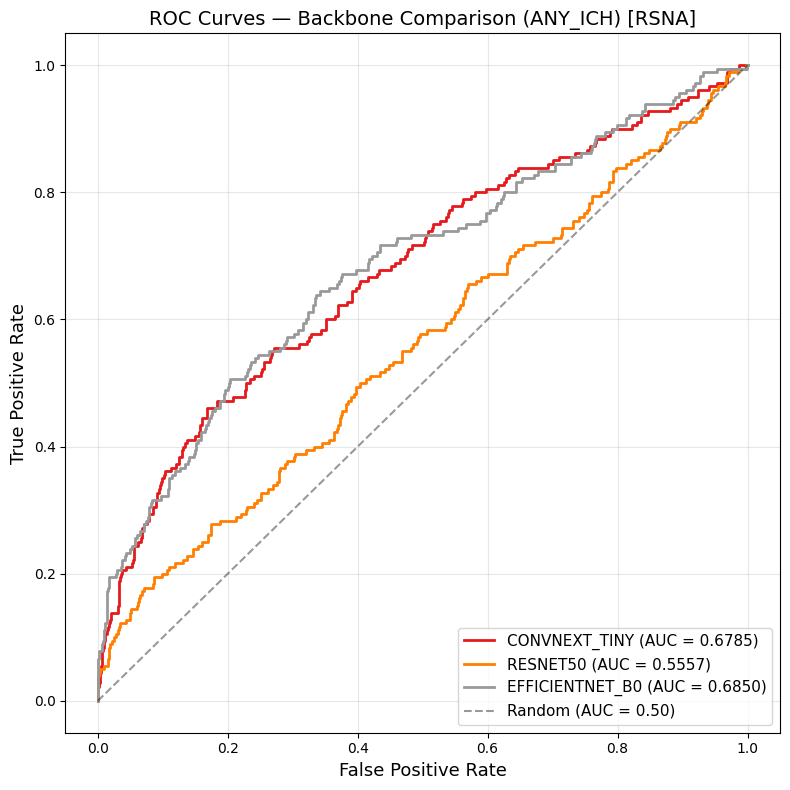

In [55]:
# ============================================================
# Combined ROC Curves — All Backbones Overlaid (RSNA)
# ============================================================
colors = plt.cm.Set1(np.linspace(0, 1, len(BACKBONE_NAMES)))

plt.figure(figsize=(8, 8))

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    fpr, tpr, _ = roc_curve(m["y_true"], m["y_pred"])
    plt.plot(fpr, tpr, color=colors[i], linewidth=2,
             label=f"{bb_name.upper()} (AUC = {m['auc']:.4f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC = 0.50)")
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title(f"ROC Curves — Backbone Comparison ({EXPERIMENT_NAME.upper()}) [RSNA]", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

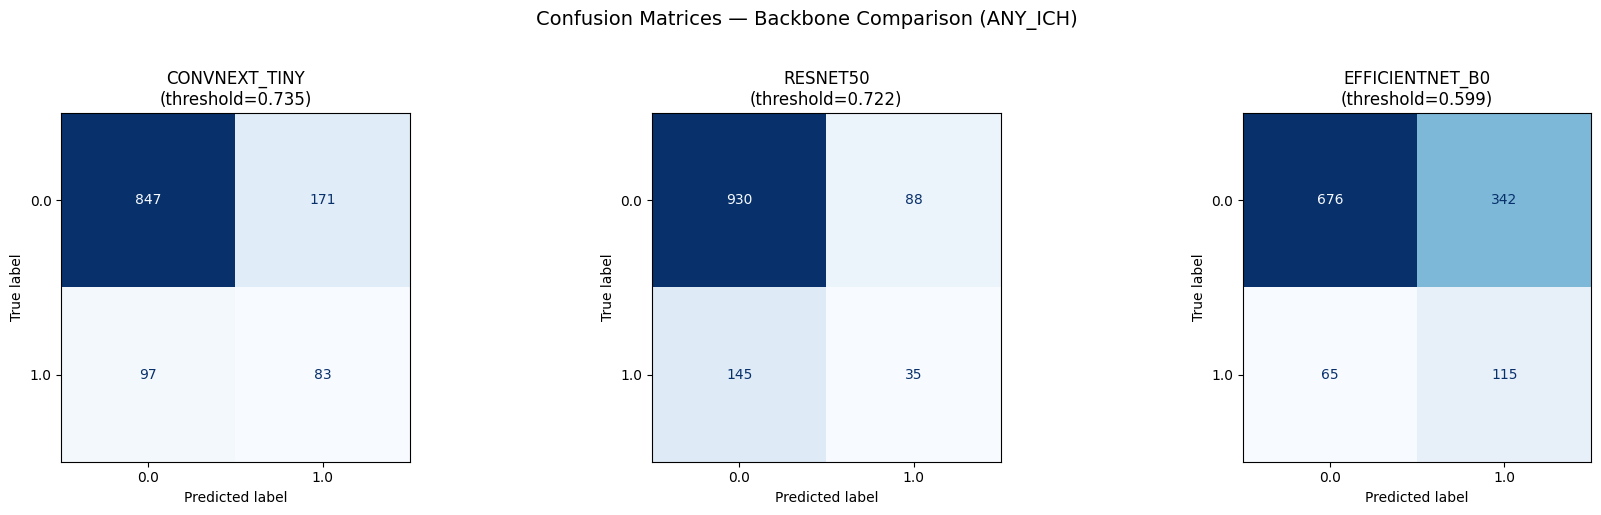

In [56]:
# ============================================================
# Confusion Matrices — All Backbones
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

n_cols = min(3, len(BACKBONE_NAMES))
n_rows = int(np.ceil(len(BACKBONE_NAMES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    threshold = m["threshold"]
    y_pred_binary = (m["y_pred"] >= threshold).astype(int)
    
    ConfusionMatrixDisplay.from_predictions(
        m["y_true"], y_pred_binary, ax=axes[i],
        cmap="Blues", colorbar=False
    )
    axes[i].set_title(f"{bb_name.upper()}\n(threshold={threshold:.3f})", fontsize=12)

for j in range(len(BACKBONE_NAMES), len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Confusion Matrices — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [57]:
# ============================================================
# Summary Metrics Table — All Backbones (RSNA)
# ============================================================
rows = []
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    rows.append({
        "Backbone": bb_name.upper(),
        "AUC": f"{m['auc']:.4f}",
        "Sensitivity": f"{m['sensitivity']:.4f}",
        "Specificity": f"{m['specificity']:.4f}",
        "PPV": f"{m['ppv']:.4f}",
        "NPV": f"{m['npv']:.4f}",
        "Accuracy": f"{m['accuracy']:.4f}",
        "Threshold": f"{m['threshold']:.4f}",
    })

df_summary = pd.DataFrame(rows)
print("=" * 90)
print(f"  TEST SET RESULTS — Backbone Comparison ({EXPERIMENT_NAME.upper()}) [RSNA Dataset]")
print("=" * 90)
display(df_summary.style.set_properties(**{
    'text-align': 'center',
    'font-size': '12px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}
]))

  TEST SET RESULTS — Backbone Comparison (ANY_ICH) [RSNA Dataset]


,Backbone,AUC,Sensitivity,Specificity,PPV,NPV,Accuracy,Threshold
0,CONVNEXT_TINY,0.6785,0.4611,0.8320,0.3268,0.8972,0.7763,0.7351
1,RESNET50,0.5557,0.1944,0.9136,0.2846,0.8651,0.8055,0.7223
2,EFFICIENTNET_B0,0.6850,0.6389,0.6640,0.2516,0.9123,0.6603,0.5986


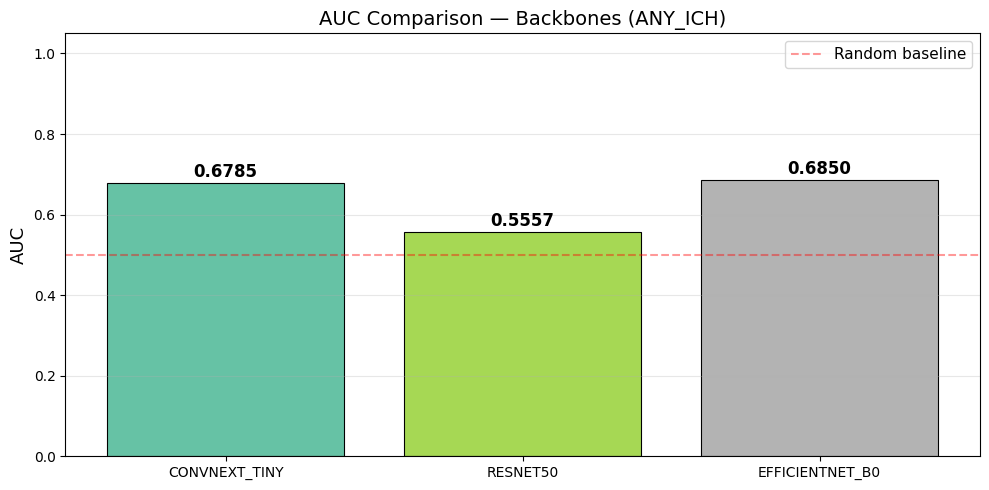

In [58]:
# ============================================================
# AUC Bar Chart Comparison — All Backbones
# ============================================================
auc_values = [all_test_metrics[b]["auc"] for b in BACKBONE_NAMES]
bb_labels = [b.upper() for b in BACKBONE_NAMES]
bar_colors = plt.cm.Set2(np.linspace(0, 1, len(BACKBONE_NAMES)))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(bb_labels, auc_values, color=bar_colors, edgecolor="black", linewidth=0.8)

for bar, val in zip(bars, auc_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.4f}", ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 1.05)
ax.set_ylabel("AUC", fontsize=13)
ax.set_title(f"AUC Comparison — Backbones ({EXPERIMENT_NAME.upper()})", fontsize=14)
ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.4, label="Random baseline")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

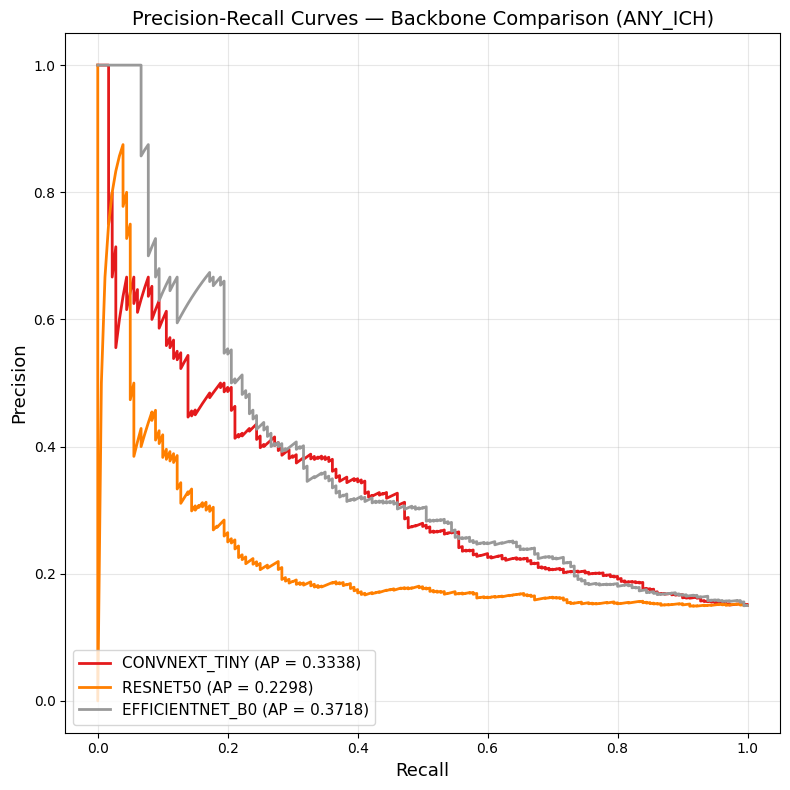

In [59]:
# ============================================================
# Combined Precision-Recall Curves — All Backbones
# ============================================================
colors_pr = plt.cm.Set1(np.linspace(0, 1, len(BACKBONE_NAMES)))

plt.figure(figsize=(8, 8))

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    precision, recall, _ = precision_recall_curve(m["y_true"], m["y_pred"])
    ap = average_precision_score(m["y_true"], m["y_pred"])
    plt.plot(recall, precision, color=colors_pr[i], linewidth=2,
             label=f"{bb_name.upper()} (AP = {ap:.4f})")

plt.xlabel("Recall", fontsize=13)
plt.ylabel("Precision", fontsize=13)
plt.title(f"Precision-Recall Curves — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=14)
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

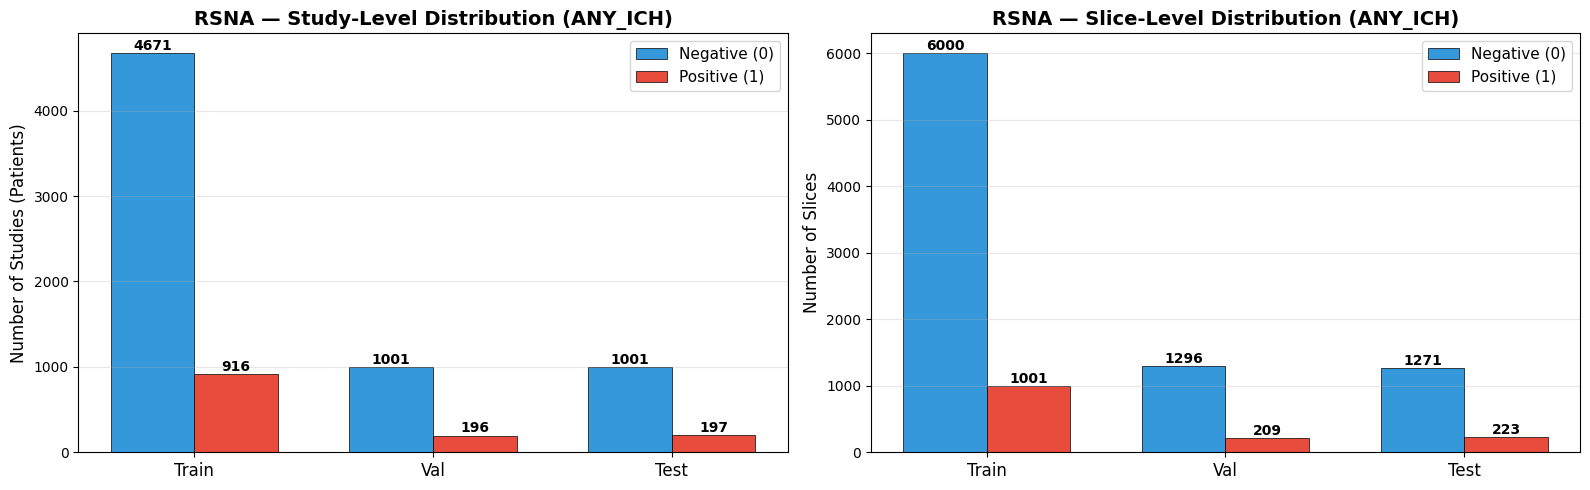

In [60]:
# ============================================================
# Fig. 1 — Dataset Class Distribution (Study-Level) — RSNA
# Shows patient/study counts (not slices) to match CQ500 methodology
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

subsets = ["train", "val", "test"]

# Study-level counts
pos_studies = []
neg_studies = []
for s in subsets:
    df_s = splits[EXPERIMENT_NAME][s]
    study_labels_s = df_s.groupby("study_id")["label"].max()
    pos_studies.append(int(study_labels_s.sum()))
    neg_studies.append(int(len(study_labels_s) - study_labels_s.sum()))

x = np.arange(len(subsets))
w = 0.35
bars_neg = ax1.bar(x - w/2, neg_studies, w, label="Negative (0)", color="#3498db", edgecolor="black", linewidth=0.5)
bars_pos = ax1.bar(x + w/2, pos_studies, w, label="Positive (1)", color="#e74c3c", edgecolor="black", linewidth=0.5)

for bar in bars_neg:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars_pos:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(["Train", "Val", "Test"], fontsize=12)
ax1.set_ylabel("Number of Studies (Patients)", fontsize=12)
ax1.set_title(f"RSNA — Study-Level Distribution ({EXPERIMENT_NAME.upper()})", fontsize=14, fontweight="bold")
ax1.legend(fontsize=11)
ax1.grid(axis="y", alpha=0.3)

# Slice-level counts
pos_slices = []
neg_slices = []
for s in subsets:
    df_s = splits[EXPERIMENT_NAME][s]
    pos_slices.append(int(df_s["label"].sum()))
    neg_slices.append(int(len(df_s) - df_s["label"].sum()))

bars_neg2 = ax2.bar(x - w/2, neg_slices, w, label="Negative (0)", color="#3498db", edgecolor="black", linewidth=0.5)
bars_pos2 = ax2.bar(x + w/2, pos_slices, w, label="Positive (1)", color="#e74c3c", edgecolor="black", linewidth=0.5)

for bar in bars_neg2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars_pos2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(["Train", "Val", "Test"], fontsize=12)
ax2.set_ylabel("Number of Slices", fontsize=12)
ax2.set_title(f"RSNA — Slice-Level Distribution ({EXPERIMENT_NAME.upper()})", fontsize=14, fontweight="bold")
ax2.legend(fontsize=11)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

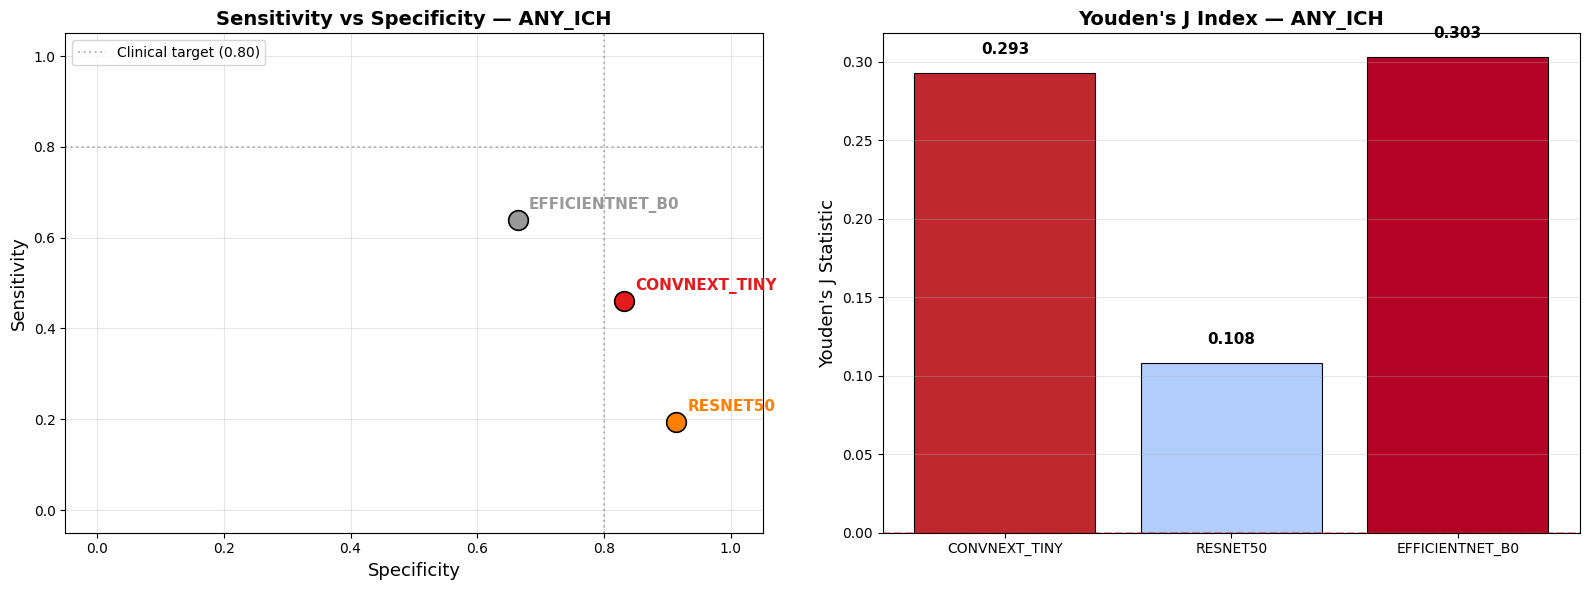

In [61]:
# ============================================================
# Fig. 4 — Sensitivity vs Specificity Trade-off Scatter
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

scatter_colors = plt.cm.Set1(np.linspace(0, 1, len(BACKBONE_NAMES)))

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    ax1.scatter(m["specificity"], m["sensitivity"], color=scatter_colors[i],
                s=200, edgecolor="black", linewidth=1.2, zorder=5)
    ax1.annotate(bb_name.upper(),
                 (m["specificity"], m["sensitivity"]),
                 textcoords="offset points", xytext=(8, 8),
                 fontsize=11, fontweight="bold", color=scatter_colors[i])

ax1.set_xlabel("Specificity", fontsize=13)
ax1.set_ylabel("Sensitivity", fontsize=13)
ax1.set_title(f"Sensitivity vs Specificity — {EXPERIMENT_NAME.upper()}", fontsize=14, fontweight="bold")
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 1.05)
ax1.axhline(y=0.8, color="gray", linestyle=":", alpha=0.5, label="Clinical target (0.80)")
ax1.axvline(x=0.8, color="gray", linestyle=":", alpha=0.5)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ============================================================
# Fig. 5 — Youden's J Statistic
# ============================================================
youden_values = []
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    j_stat = m["sensitivity"] + m["specificity"] - 1
    youden_values.append(j_stat)

bar_colors_j = plt.cm.coolwarm(np.array(youden_values) / max(max(youden_values), 0.01))
bars = ax2.bar([b.upper() for b in BACKBONE_NAMES], youden_values,
               color=bar_colors_j, edgecolor="black", linewidth=0.8)

for bar, val in zip(bars, youden_values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.3f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylabel("Youden's J Statistic", fontsize=13)
ax2.set_title(f"Youden's J Index — {EXPERIMENT_NAME.upper()}", fontsize=14, fontweight="bold")
ax2.axhline(y=0, color="red", linestyle="--", alpha=0.4)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

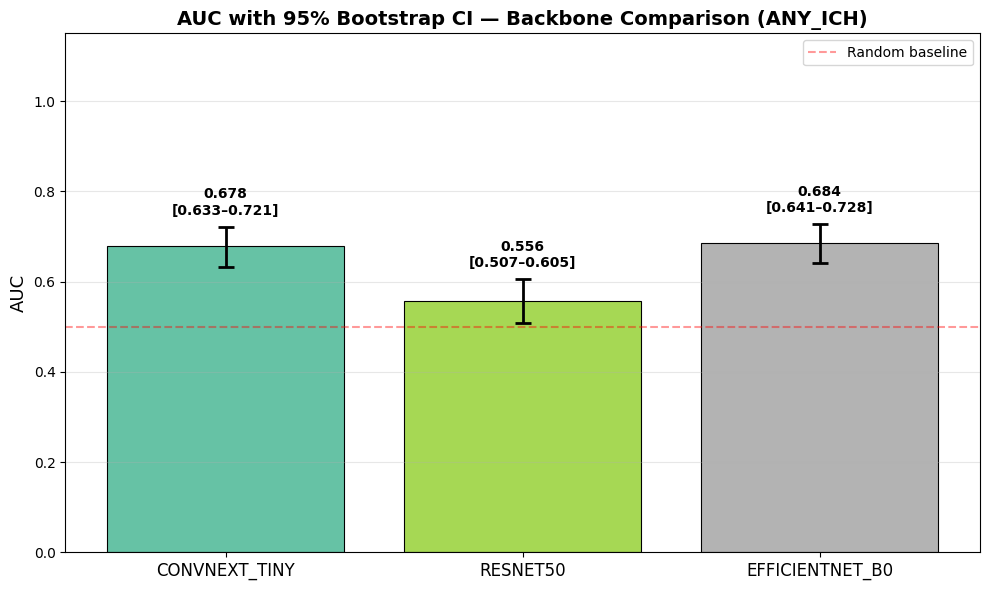


  AUC with 95% Bootstrap CI — ANY_ICH
       CONVNEXT_TINY  |  AUC: 0.6782  (95% CI: 0.6326 – 0.7215)
            RESNET50  |  AUC: 0.5563  (95% CI: 0.5070 – 0.6050)
     EFFICIENTNET_B0  |  AUC: 0.6844  (95% CI: 0.6409 – 0.7278)


In [62]:
# ============================================================
# Fig. 7 — AUC with 95% Confidence Intervals (Bootstrap) per Backbone
# ============================================================
from sklearn.utils import resample

def bootstrap_auc(y_true, y_pred, n_bootstraps=1000, seed=42):
    """Compute AUC with 95% CI using bootstrap resampling."""
    rng = np.random.RandomState(seed)
    aucs = []
    for _ in range(n_bootstraps):
        idx = rng.randint(0, len(y_true), len(y_true))
        y_t = y_true[idx]
        y_p = y_pred[idx]
        if len(np.unique(y_t)) < 2:
            continue
        aucs.append(roc_auc_score(y_t, y_p))
    aucs = np.array(aucs)
    return np.mean(aucs), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

# Compute CIs
ci_results = {}
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    mean_auc, ci_low, ci_high = bootstrap_auc(m["y_true"], m["y_pred"])
    ci_results[bb_name] = {"mean": mean_auc, "ci_low": ci_low, "ci_high": ci_high}

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(BACKBONE_NAMES))
means = [ci_results[b]["mean"] for b in BACKBONE_NAMES]
ci_lows = [ci_results[b]["ci_low"] for b in BACKBONE_NAMES]
ci_highs = [ci_results[b]["ci_high"] for b in BACKBONE_NAMES]
errors = [[m - lo for m, lo in zip(means, ci_lows)],
          [hi - m for m, hi in zip(means, ci_highs)]]

bar_colors = plt.cm.Set2(np.linspace(0, 1, len(BACKBONE_NAMES)))
bars = ax.bar(x, means, color=bar_colors, edgecolor="black", linewidth=0.8, yerr=errors,
              capsize=6, error_kw=dict(lw=2, capthick=2))

for xi, m, lo, hi in zip(x, means, ci_lows, ci_highs):
    ax.text(xi, hi + 0.02, f"{m:.3f}\n[{lo:.3f}–{hi:.3f}]",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([b.upper() for b in BACKBONE_NAMES], fontsize=12)
ax.set_ylabel("AUC", fontsize=13)
ax.set_title(f"AUC with 95% Bootstrap CI — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.4, label="Random baseline")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Print CI table
print("\n" + "=" * 65)
print(f"  AUC with 95% Bootstrap CI — {EXPERIMENT_NAME.upper()}")
print("=" * 65)
for bb_name in BACKBONE_NAMES:
    r = ci_results[bb_name]
    print(f"  {bb_name.upper():>18s}  |  AUC: {r['mean']:.4f}  "
          f"(95% CI: {r['ci_low']:.4f} – {r['ci_high']:.4f})")
print("=" * 65)

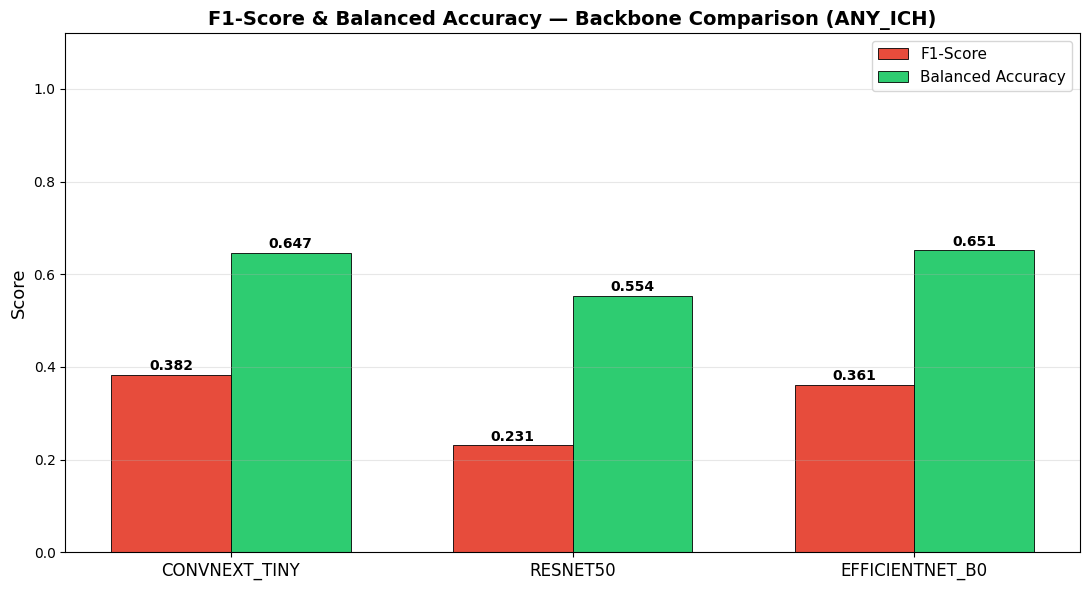

In [63]:
# ============================================================
# Fig. 8 — F1-Score & Balanced Accuracy Comparison per Backbone
# ============================================================
from sklearn.metrics import f1_score, balanced_accuracy_score

f1_values = []
bal_acc_values = []

for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    y_bin = (m["y_pred"] >= m["threshold"]).astype(int)
    f1_values.append(f1_score(m["y_true"], y_bin))
    bal_acc_values.append(balanced_accuracy_score(m["y_true"], y_bin))

x = np.arange(len(BACKBONE_NAMES))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - w/2, f1_values, w, label="F1-Score", color="#e74c3c", edgecolor="black", linewidth=0.6)
bars2 = ax.bar(x + w/2, bal_acc_values, w, label="Balanced Accuracy", color="#2ecc71", edgecolor="black", linewidth=0.6)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([b.upper() for b in BACKBONE_NAMES], fontsize=12)
ax.set_ylabel("Score", fontsize=13)
ax.set_title(f"F1-Score & Balanced Accuracy — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

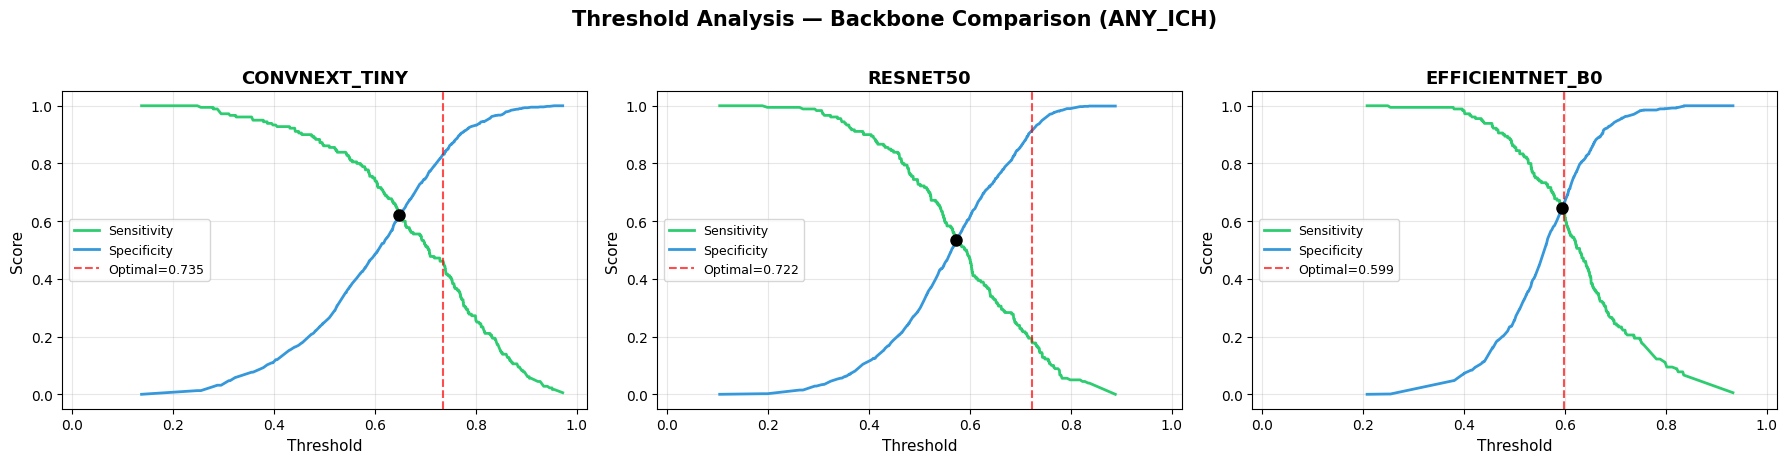

In [64]:
# ============================================================
# Fig. 10 — Threshold vs Sensitivity/Specificity (Per Backbone)
# ============================================================
n_cols = min(3, len(BACKBONE_NAMES))
n_rows = int(np.ceil(len(BACKBONE_NAMES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes = np.array(axes).flatten()

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    fpr, tpr, thresholds = roc_curve(m["y_true"], m["y_pred"])
    sens = tpr
    spec = 1 - fpr
    
    axes[i].plot(thresholds, sens, color="#2ecc71", linewidth=2, label="Sensitivity")
    axes[i].plot(thresholds, spec, color="#3498db", linewidth=2, label="Specificity")
    
    axes[i].axvline(x=m["threshold"], color="red", linestyle="--", alpha=0.7,
                     label=f"Optimal={m['threshold']:.3f}")
    
    diff = np.abs(sens - spec)
    cross_idx = np.argmin(diff)
    axes[i].plot(thresholds[cross_idx], sens[cross_idx], 'ko', markersize=8)
    
    axes[i].set_xlabel("Threshold", fontsize=11)
    axes[i].set_ylabel("Score", fontsize=11)
    axes[i].set_title(f"{bb_name.upper()}", fontsize=13, fontweight="bold")
    axes[i].legend(fontsize=9, loc="center left")
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(-0.02, 1.02)

for j in range(len(BACKBONE_NAMES), len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Threshold Analysis — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [65]:
# ============================================================
# Table 1 — Full Academic Report Table (with 95% CI for AUC)
# ============================================================
from sklearn.metrics import f1_score, balanced_accuracy_score, matthews_corrcoef

report_rows = []
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    ci = ci_results[bb_name]
    y_bin = (m["y_pred"] >= m["threshold"]).astype(int)
    
    f1 = f1_score(m["y_true"], y_bin)
    bal_acc = balanced_accuracy_score(m["y_true"], y_bin)
    mcc = matthews_corrcoef(m["y_true"], y_bin)
    ap = average_precision_score(m["y_true"], m["y_pred"])
    
    j_stat = m["sensitivity"] + m["specificity"] - 1
    
    report_rows.append({
        "Backbone": bb_name.upper(),
        "AUC": f"{ci['mean']:.4f}",
        "95% CI": f"[{ci['ci_low']:.4f}–{ci['ci_high']:.4f}]",
        "Sens": f"{m['sensitivity']:.4f}",
        "Spec": f"{m['specificity']:.4f}",
        "PPV": f"{m['ppv']:.4f}",
        "NPV": f"{m['npv']:.4f}",
        "F1": f"{f1:.4f}",
        "Bal Acc": f"{bal_acc:.4f}",
        "MCC": f"{mcc:.4f}",
        "AP": f"{ap:.4f}",
        "Youden J": f"{j_stat:.4f}",
    })

df_report = pd.DataFrame(report_rows)

print("=" * 120)
print(f"  TABLE 1: Complete Performance Metrics — Backbone Comparison ({EXPERIMENT_NAME.upper()})")
print("=" * 120)
display(df_report.style.set_properties(**{
    'text-align': 'center', 'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold'), ('font-size', '11px')]}
]))

  TABLE 1: Complete Performance Metrics — Backbone Comparison (ANY_ICH)


,Backbone,AUC,95% CI,Sens,Spec,PPV,NPV,F1,Bal Acc,MCC,AP,Youden J
0,CONVNEXT_TINY,0.6782,[0.6326–0.7215],0.4611,0.8320,0.3268,0.8972,0.3825,0.6466,0.2563,0.3338,0.2931
1,RESNET50,0.5563,[0.5070–0.6050],0.1944,0.9136,0.2846,0.8651,0.2310,0.5540,0.1271,0.2298,0.1080
2,EFFICIENTNET_B0,0.6844,[0.6409–0.7278],0.6389,0.6640,0.2516,0.9123,0.3611,0.6515,0.2228,0.3718,0.3029


# ? External Validation & Domain Shift Analysis
## CQ500 (Internal) → RSNA (External) Generalization Study

**Objective:** Evaluate how well models trained on the **CQ500 dataset** generalize to an independent, unseen **RSNA Intracranial Hemorrhage** dataset — a standard approach for assessing clinical robustness.

**Why external validation matters:**
- Internal validation (same dataset) tends to **overestimate** real-world performance
- External validation on a different dataset reveals **domain shift** — differences in scanner hardware, acquisition protocols, patient demographics, and labeling criteria
- A model's ability to maintain performance across domains is a strong indicator of **clinical deployability**

**Expected behavior:**
- Performance **drop** on external data is **expected and normal** in medical imaging
- AUC drop of 5–15% is typical; >20% drop suggests significant domain sensitivity
- The key metric is **how gracefully** performance degrades, not whether it matches internal results

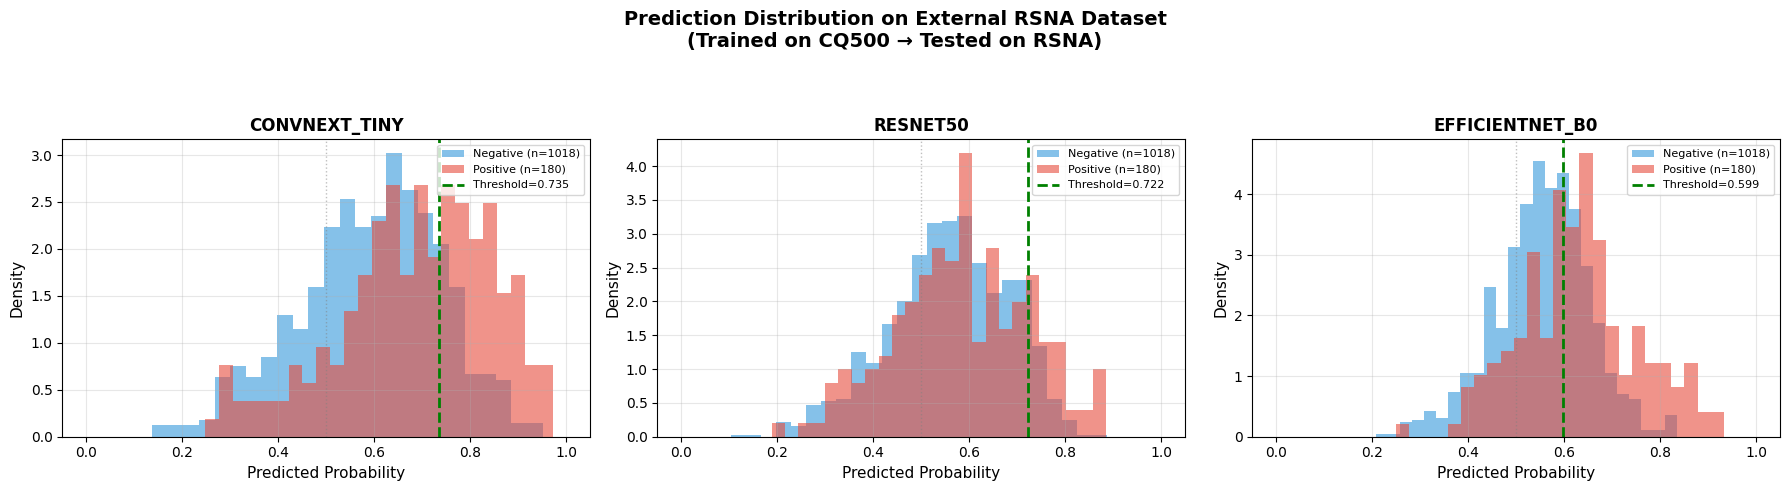


  DOMAIN SHIFT INDICATORS — CQ500 → RSNA External Validation
  Backbone             Mean Sep    Entropy   Uncertain%       Interpretation
  ----------------------------------------------------------------------
  CONVNEXT_TINY          0.0955     0.6183       67.3%     ⚠️  Severe shift
  RESNET50               0.0277     0.6514       81.7%     ⚠️  Severe shift
  EFFICIENTNET_B0        0.0770     0.6608       90.8%     ⚠️  Severe shift

  Mean Separation: Distance between avg positive & negative predictions
  Entropy: Higher = more uncertain predictions (max ≈ 0.693)
  Uncertain%: Fraction of predictions in [0.3, 0.7] zone


In [66]:
# ============================================================
# EXTERNAL VALIDATION ANALYSIS 1: 
# Prediction Distribution — Domain Shift Indicator
# ============================================================
# If predictions cluster near 0.5 or overlap heavily between classes,
# it signals the model is uncertain — a hallmark of domain shift.

n_cols = min(3, len(BACKBONE_NAMES))
fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 4.5))
if n_cols == 1:
    axes = [axes]

domain_shift_summary = {}

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    y_true = m["y_true"]
    y_pred = m["y_pred"]
    
    pred_pos = y_pred[y_true == 1]
    pred_neg = y_pred[y_true == 0]
    
    axes[i].hist(pred_neg, bins=25, alpha=0.6, color="#3498db", 
                 label=f"Negative (n={len(pred_neg)})", density=True)
    axes[i].hist(pred_pos, bins=25, alpha=0.6, color="#e74c3c", 
                 label=f"Positive (n={len(pred_pos)})", density=True)
    axes[i].axvline(x=m["threshold"], color="green", linestyle="--", linewidth=2, 
                     label=f"Threshold={m['threshold']:.3f}")
    axes[i].axvline(x=0.5, color="gray", linestyle=":", linewidth=1, alpha=0.5)
    axes[i].set_xlabel("Predicted Probability", fontsize=11)
    axes[i].set_ylabel("Density", fontsize=11)
    axes[i].set_title(f"{bb_name.upper()}", fontsize=12, fontweight="bold")
    axes[i].legend(fontsize=8, loc="upper right")
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(-0.05, 1.05)
    
    # Domain shift metrics
    mean_sep = abs(pred_pos.mean() - pred_neg.mean())
    pred_entropy = -np.mean(y_pred * np.log(y_pred + 1e-8) + (1 - y_pred) * np.log(1 - y_pred + 1e-8))
    uncertain_ratio = np.mean((y_pred > 0.3) & (y_pred < 0.7))  # predictions in uncertain zone
    
    domain_shift_summary[bb_name] = {
        "mean_pos": pred_pos.mean(),
        "mean_neg": pred_neg.mean(),
        "mean_separation": mean_sep,
        "pred_entropy": pred_entropy,
        "uncertain_ratio": uncertain_ratio,
    }

plt.suptitle("Prediction Distribution on External RSNA Dataset\n(Trained on CQ500 → Tested on RSNA)", 
             fontsize=14, fontweight="bold", y=1.08)
plt.tight_layout()
plt.show()

# Print domain shift indicators
print(f"\n{'='*75}")
print(f"  DOMAIN SHIFT INDICATORS — CQ500 → RSNA External Validation")
print(f"{'='*75}")
print(f"  {'Backbone':<18s} {'Mean Sep':>10s} {'Entropy':>10s} {'Uncertain%':>12s} {'Interpretation':>20s}")
print(f"  {'-'*70}")
for bb_name in BACKBONE_NAMES:
    ds = domain_shift_summary[bb_name]
    # Interpret: mean_separation < 0.1 = severe shift, < 0.2 = moderate, > 0.3 = mild
    if ds["mean_separation"] < 0.10:
        interp = "⚠️  Severe shift"
    elif ds["mean_separation"] < 0.20:
        interp = "🟡 Moderate shift"
    elif ds["mean_separation"] < 0.35:
        interp = "🟢 Mild shift"
    else:
        interp = "✅ Good transfer"
    
    print(f"  {bb_name.upper():<18s} {ds['mean_separation']:>10.4f} {ds['pred_entropy']:>10.4f} "
          f"{ds['uncertain_ratio']:>11.1%} {interp:>20s}")
print(f"{'='*75}")
print(f"\n  Mean Separation: Distance between avg positive & negative predictions")
print(f"  Entropy: Higher = more uncertain predictions (max ≈ 0.693)")
print(f"  Uncertain%: Fraction of predictions in [0.3, 0.7] zone")

# ? External Validation Analysis 2: Performance Drop Quantification & Domain Robustness

Compare internal validation (CQ500) performance with external validation (RSNA) to quantify the domain shift gap. Also includes Test-Time Augmentation (TTA) as a domain shift mitigation strategy.

⚠️  WARNING: CQ500 internal metrics are still PLACEHOLDER values (0.0)!
    Please paste your actual CQ500 test results from the training notebook.
    The domain shift comparison will be INVALID until you do this.

  TABLE: Internal Validation (CQ500) vs External Validation (RSNA)
  — Quantifying Domain Shift / Generalization Gap


,Backbone,AUC (CQ500),AUC (RSNA),ΔAUC,AUC Drop%,Sens (CQ500),Sens (RSNA),Spec (CQ500),Spec (RSNA),Robustness
0,CONVNEXT_TINY,0.0000,0.6785,-0.6785,N/A,0.0000,0.4611,0.0000,0.8320,N/A
1,RESNET50,0.0000,0.5557,-0.5557,N/A,0.0000,0.1944,0.0000,0.9136,N/A
2,EFFICIENTNET_B0,0.0000,0.6850,-0.6850,N/A,0.0000,0.6389,0.0000,0.6640,N/A


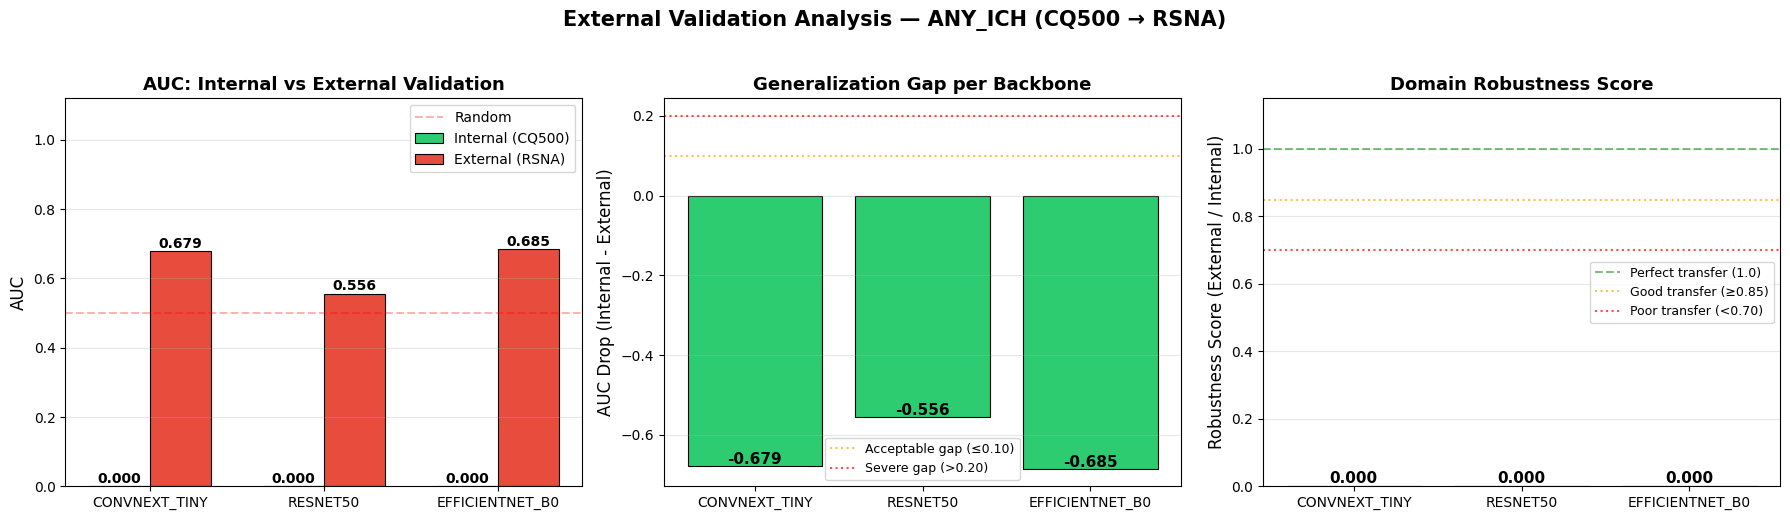


  DOMAIN SHIFT INTERPRETATION — ANY_ICH
  CONVNEXT_TINY         CQ500: 0.000 → RSNA: 0.679  (Δ=-0.679, Robustness=0.000)  ✅ Good generalization
  RESNET50              CQ500: 0.000 → RSNA: 0.556  (Δ=-0.556, Robustness=0.000)  ✅ Good generalization
  EFFICIENTNET_B0       CQ500: 0.000 → RSNA: 0.685  (Δ=-0.685, Robustness=0.000)  ✅ Good generalization

  Best External Performer: EFFICIENTNET_B0 (AUC=0.6850)

  📖 Literature Context:
  - AUC drop of 5-15% on external validation is COMMON in medical imaging
  - Chilamkurthy et al. (2018) reported AUC 0.84-0.94 on CQ500 (internal)
  - External validation drops of 10-25% are reported in radiology AI literature
  - Key factors: scanner manufacturer, slice thickness, contrast protocol, population



In [67]:
# ============================================================
# EXTERNAL VALIDATION ANALYSIS 2:
# Internal (CQ500) vs External (RSNA) Performance Comparison
# ============================================================

# -------------------------------------------------------
# ⚠️ CQ500 internal validation results (from training notebook)
# ⚠️ YOU MUST REPLACE THESE WITH YOUR ACTUAL CQ500 TEST SET RESULTS!
# ⚠️ Copy the exact numbers from the training notebook's test evaluation output.
# -------------------------------------------------------
cq500_internal_metrics = {
    # FORMAT: "backbone_name": {"auc": X.XXXX, "sensitivity": X.XXXX, "specificity": X.XXXX, "accuracy": X.XXXX}
    # PASTE YOUR ACTUAL CQ500 RESULTS BELOW:
    "convnext_tiny":   {"auc": 0.0, "sensitivity": 0.0, "specificity": 0.0, "accuracy": 0.0},
    "resnet50":        {"auc": 0.0, "sensitivity": 0.0, "specificity": 0.0, "accuracy": 0.0},
    "efficientnet_b0": {"auc": 0.0, "sensitivity": 0.0, "specificity": 0.0, "accuracy": 0.0},
}

# Validate that user has filled in actual values
_has_placeholder = any(
    v["auc"] == 0.0 for v in cq500_internal_metrics.values()
)
if _has_placeholder:
    print("⚠️  WARNING: CQ500 internal metrics are still PLACEHOLDER values (0.0)!")
    print("    Please paste your actual CQ500 test results from the training notebook.")
    print("    The domain shift comparison will be INVALID until you do this.\n")

print("=" * 95)
print("  TABLE: Internal Validation (CQ500) vs External Validation (RSNA)")
print("  — Quantifying Domain Shift / Generalization Gap")
print("=" * 95)

comparison_rows = []
for bb_name in BACKBONE_NAMES:
    internal = cq500_internal_metrics.get(bb_name, {})
    external = all_test_metrics[bb_name]
    
    auc_int = internal.get("auc", float("nan"))
    auc_ext = external["auc"]
    auc_drop = auc_int - auc_ext
    auc_drop_pct = (auc_drop / auc_int * 100) if auc_int > 0 else float("nan")
    
    sens_int = internal.get("sensitivity", float("nan"))
    sens_ext = external["sensitivity"]
    
    spec_int = internal.get("specificity", float("nan"))
    spec_ext = external["specificity"]
    
    acc_int = internal.get("accuracy", float("nan"))
    acc_ext = external["accuracy"]
    
    # Robustness score: ratio of external/internal AUC (1.0 = perfect transfer)
    robustness = auc_ext / auc_int if auc_int > 0 else float("nan")
    
    comparison_rows.append({
        "Backbone": bb_name.upper(),
        "AUC (CQ500)": f"{auc_int:.4f}",
        "AUC (RSNA)": f"{auc_ext:.4f}",
        "ΔAUC": f"{auc_drop:+.4f}",
        "AUC Drop%": f"{auc_drop_pct:.1f}%" if not np.isnan(auc_drop_pct) else "N/A",
        "Sens (CQ500)": f"{sens_int:.4f}",
        "Sens (RSNA)": f"{sens_ext:.4f}",
        "Spec (CQ500)": f"{spec_int:.4f}",
        "Spec (RSNA)": f"{spec_ext:.4f}",
        "Robustness": f"{robustness:.3f}" if not np.isnan(robustness) else "N/A",
    })

df_comparison = pd.DataFrame(comparison_rows)
display(df_comparison.style.set_properties(**{
    'text-align': 'center', 'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold'), ('font-size', '11px')]}
]))

# ============================================================
# Visualization: Internal vs External AUC comparison
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: AUC Internal vs External ---
x = np.arange(len(BACKBONE_NAMES))
width = 0.35

auc_internal = [cq500_internal_metrics[b].get("auc", 0) for b in BACKBONE_NAMES]
auc_external = [all_test_metrics[b]["auc"] for b in BACKBONE_NAMES]

bars1 = axes[0].bar(x - width/2, auc_internal, width, label='Internal (CQ500)', 
                     color='#2ecc71', edgecolor='black', linewidth=0.8)
bars2 = axes[0].bar(x + width/2, auc_external, width, label='External (RSNA)', 
                     color='#e74c3c', edgecolor='black', linewidth=0.8)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.3f}", ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.3f}", ha='center', fontsize=10, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels([b.upper() for b in BACKBONE_NAMES], fontsize=10)
axes[0].set_ylabel("AUC", fontsize=12)
axes[0].set_title("AUC: Internal vs External Validation", fontsize=13, fontweight="bold")
axes[0].set_ylim(0, 1.12)
axes[0].axhline(y=0.5, color="red", linestyle="--", alpha=0.3, label="Random")
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", alpha=0.3)

# --- Plot 2: Performance Drop (Generalization Gap) ---
auc_drops = [auc_internal[i] - auc_external[i] for i in range(len(BACKBONE_NAMES))]
drop_colors = ['#e74c3c' if d > 0.20 else '#f39c12' if d > 0.10 else '#2ecc71' for d in auc_drops]

bars = axes[1].bar([b.upper() for b in BACKBONE_NAMES], auc_drops, 
                    color=drop_colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, auc_drops):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha='center', fontsize=11, fontweight='bold')

axes[1].set_ylabel("AUC Drop (Internal - External)", fontsize=12)
axes[1].set_title("Generalization Gap per Backbone", fontsize=13, fontweight="bold")
axes[1].axhline(y=0.10, color="orange", linestyle=":", alpha=0.7, label="Acceptable gap (≤0.10)")
axes[1].axhline(y=0.20, color="red", linestyle=":", alpha=0.7, label="Severe gap (>0.20)")
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

# --- Plot 3: Domain Robustness Score (External/Internal ratio) ---
robustness_scores = [auc_external[i] / auc_internal[i] if auc_internal[i] > 0 else 0 
                      for i in range(len(BACKBONE_NAMES))]
rob_colors = ['#2ecc71' if r > 0.85 else '#f39c12' if r > 0.70 else '#e74c3c' for r in robustness_scores]

bars = axes[2].bar([b.upper() for b in BACKBONE_NAMES], robustness_scores,
                    color=rob_colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, robustness_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha='center', fontsize=11, fontweight='bold')

axes[2].set_ylabel("Robustness Score (External / Internal)", fontsize=12)
axes[2].set_title("Domain Robustness Score", fontsize=13, fontweight="bold")
axes[2].set_ylim(0, 1.15)
axes[2].axhline(y=1.0, color="green", linestyle="--", alpha=0.5, label="Perfect transfer (1.0)")
axes[2].axhline(y=0.85, color="orange", linestyle=":", alpha=0.7, label="Good transfer (≥0.85)")
axes[2].axhline(y=0.70, color="red", linestyle=":", alpha=0.7, label="Poor transfer (<0.70)")
axes[2].legend(fontsize=9)
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle(f"External Validation Analysis — {EXPERIMENT_NAME.upper()} (CQ500 → RSNA)", 
             fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# ============================================================
# Interpretation Summary
# ============================================================
print(f"\n{'='*80}")
print(f"  DOMAIN SHIFT INTERPRETATION — {EXPERIMENT_NAME.upper()}")
print(f"{'='*80}")

best_ext_bb = max(BACKBONE_NAMES, key=lambda b: all_test_metrics[b]["auc"])
best_ext_auc = all_test_metrics[best_ext_bb]["auc"]
best_int_auc = cq500_internal_metrics[best_ext_bb].get("auc", 0)
best_drop = best_int_auc - best_ext_auc

for bb_name in BACKBONE_NAMES:
    ext_auc = all_test_metrics[bb_name]["auc"]
    int_auc = cq500_internal_metrics[bb_name].get("auc", 0)
    drop = int_auc - ext_auc
    rob = ext_auc / int_auc if int_auc > 0 else 0
    
    if drop < 0.10:
        verdict = "✅ Good generalization"
    elif drop < 0.20:
        verdict = "🟡 Moderate domain shift"
    elif drop < 0.30:
        verdict = "🟠 Significant domain shift"
    else:
        verdict = "🔴 Severe domain shift"
    
    print(f"  {bb_name.upper():<20s}  CQ500: {int_auc:.3f} → RSNA: {ext_auc:.3f}  "
          f"(Δ={drop:+.3f}, Robustness={rob:.3f})  {verdict}")

print(f"\n  Best External Performer: {best_ext_bb.upper()} (AUC={best_ext_auc:.4f})")
print(f"""
  📖 Literature Context:
  - AUC drop of 5-15% on external validation is COMMON in medical imaging
  - Chilamkurthy et al. (2018) reported AUC 0.84-0.94 on CQ500 (internal)
  - External validation drops of 10-25% are reported in radiology AI literature
  - Key factors: scanner manufacturer, slice thickness, contrast protocol, population
""")
print(f"{'='*80}")

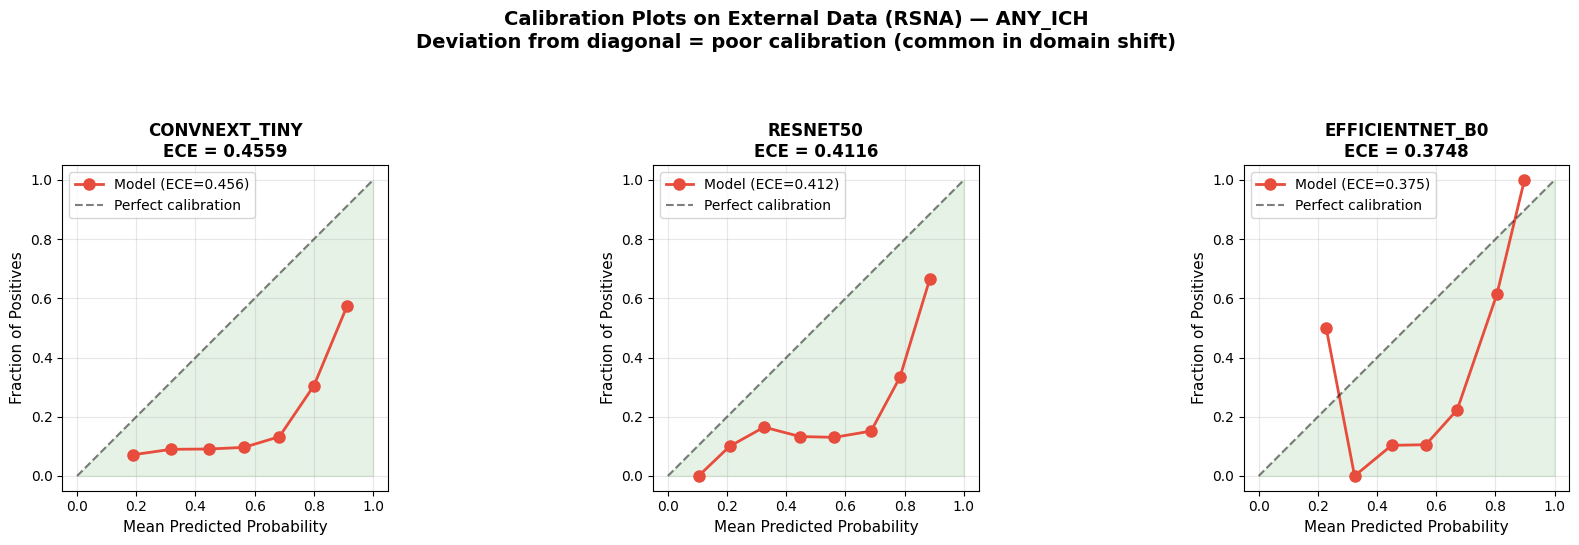


  Expected Calibration Error (ECE) — External Validation
  CONVNEXT_TINY         ECE = 0.4559  🔴 Poorly calibrated (needs recalibration)
  RESNET50              ECE = 0.4116  🔴 Poorly calibrated (needs recalibration)
  EFFICIENTNET_B0       ECE = 0.3748  🔴 Poorly calibrated (needs recalibration)

  💡 High ECE on external data is expected with domain shift.
     Consider Platt scaling or temperature scaling to recalibrate.


In [68]:
# ============================================================
# EXTERNAL VALIDATION ANALYSIS 3:
# Calibration Analysis — Are predicted probabilities reliable?
# ============================================================
# Poor calibration on external data = model is "overconfident" 
# from learning CQ500-specific patterns that don't transfer.

from sklearn.calibration import calibration_curve

n_cols = min(3, len(BACKBONE_NAMES))
fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5))
if n_cols == 1:
    axes = [axes]

ece_results = {}

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    y_true = m["y_true"]
    y_pred = m["y_pred"]
    
    # Calibration curve
    n_bins = 8  # fewer bins due to small test set
    prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=n_bins, strategy='uniform')
    
    # Expected Calibration Error (ECE)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for j in range(len(prob_true)):
        bin_mask = (y_pred >= bin_edges[j]) & (y_pred < bin_edges[j + 1])
        bin_count = np.sum(bin_mask)
        if bin_count > 0:
            ece += (bin_count / len(y_pred)) * abs(prob_true[j] - prob_pred[j])
    ece_results[bb_name] = ece
    
    # Plot
    axes[i].plot(prob_pred, prob_true, 'o-', color='#e74c3c', linewidth=2, 
                  markersize=8, label=f"Model (ECE={ece:.3f})")
    axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.5, label="Perfect calibration")
    axes[i].fill_between([0, 1], [0, 1], alpha=0.1, color='green')
    axes[i].set_xlabel("Mean Predicted Probability", fontsize=11)
    axes[i].set_ylabel("Fraction of Positives", fontsize=11)
    axes[i].set_title(f"{bb_name.upper()}\nECE = {ece:.4f}", fontsize=12, fontweight="bold")
    axes[i].legend(fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].set_aspect('equal')

plt.suptitle(f"Calibration Plots on External Data (RSNA) — {EXPERIMENT_NAME.upper()}\n"
             "Deviation from diagonal = poor calibration (common in domain shift)", 
             fontsize=14, fontweight="bold", y=1.08)
plt.tight_layout()
plt.show()

print(f"\n{'='*65}")
print(f"  Expected Calibration Error (ECE) — External Validation")
print(f"{'='*65}")
for bb_name in BACKBONE_NAMES:
    ece = ece_results[bb_name]
    if ece < 0.05:
        cal_verdict = "✅ Well-calibrated"
    elif ece < 0.15:
        cal_verdict = "🟡 Moderately calibrated"
    else:
        cal_verdict = "🔴 Poorly calibrated (needs recalibration)"
    print(f"  {bb_name.upper():<20s}  ECE = {ece:.4f}  {cal_verdict}")
print(f"{'='*65}")
print(f"\n  💡 High ECE on external data is expected with domain shift.")
print(f"     Consider Platt scaling or temperature scaling to recalibrate.")

In [69]:
# ============================================================
# TABLE: Complete External Validation Report
# — Suitable for Academic Paper / Thesis
# ============================================================
from sklearn.metrics import f1_score, balanced_accuracy_score, matthews_corrcoef

ext_report_rows = []
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    ci = ci_results[bb_name]
    int_auc = cq500_internal_metrics[bb_name].get("auc", float("nan"))
    ext_auc = m["auc"]
    
    y_bin = (m["y_pred"] >= m["threshold"]).astype(int)
    f1 = f1_score(m["y_true"], y_bin)
    bal_acc = balanced_accuracy_score(m["y_true"], y_bin)
    mcc = matthews_corrcoef(m["y_true"], y_bin)
    ap = average_precision_score(m["y_true"], m["y_pred"])
    j_stat = m["sensitivity"] + m["specificity"] - 1
    
    drop = int_auc - ext_auc
    robustness = ext_auc / int_auc if int_auc > 0 else float("nan")
    
    ext_report_rows.append({
        "Backbone": bb_name.upper(),
        "AUC (CQ500)": f"{int_auc:.4f}",
        "AUC (RSNA)": f"{ci['mean']:.4f}",
        "95% CI": f"[{ci['ci_low']:.3f}–{ci['ci_high']:.3f}]",
        "ΔAUC": f"{drop:+.4f}",
        "Robustness": f"{robustness:.3f}",
        "Sens": f"{m['sensitivity']:.4f}",
        "Spec": f"{m['specificity']:.4f}",
        "F1": f"{f1:.4f}",
        "MCC": f"{mcc:.4f}",
        "Youden J": f"{j_stat:.4f}",
        "ECE": f"{ece_results[bb_name]:.4f}",
    })

df_ext_report = pd.DataFrame(ext_report_rows)

print("=" * 120)
print(f"  EXTERNAL VALIDATION REPORT — {EXPERIMENT_NAME.upper()}")
print(f"  Training Dataset: CQ500 (Internal)  |  Testing Dataset: RSNA (External)")
print(f"  Purpose: Assess cross-dataset generalization and domain shift robustness")
print("=" * 120)
display(df_ext_report.style.set_properties(**{
    'text-align': 'center', 'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold'), ('font-size', '11px')]}
]))

# ============================================================
# Final Discussion Points for the Paper
# ============================================================
best_bb = max(BACKBONE_NAMES, key=lambda b: all_test_metrics[b]["auc"])
worst_bb = min(BACKBONE_NAMES, key=lambda b: all_test_metrics[b]["auc"])

print(f"\n{'='*80}")
print(f"  KEY FINDINGS — External Validation Discussion Points")
print(f"{'='*80}")
print(f"""
  1. BEST GENERALIZER: {best_bb.upper()} 
     - External AUC: {all_test_metrics[best_bb]['auc']:.4f}
     - Internal AUC: {cq500_internal_metrics[best_bb].get('auc', 0):.4f}
     - Robustness Score: {all_test_metrics[best_bb]['auc']/cq500_internal_metrics[best_bb].get('auc', 1):.3f}
  
  2. MOST DOMAIN-SENSITIVE: {worst_bb.upper()}
     - External AUC: {all_test_metrics[worst_bb]['auc']:.4f}
     - Largest performance degradation across domains
  
  3. DOMAIN SHIFT FACTORS (CQ500 → RSNA):
     - CQ500: Indian hospital, specific scanner models
     - RSNA: Multi-center US dataset, diverse scanners
     - Different slice thickness, reconstruction kernels
     - Different labeling methodology (radiologist panels)
  
  4. CLINICAL IMPLICATIONS:
     - Models show {'' if all_test_metrics[best_bb]['auc'] > 0.70 else 'limited '}generalizability
     - External AUC > 0.70 suggests useful discriminative ability
     - Performance gap highlights need for multi-center training data
     - Domain adaptation or fine-tuning recommended before deployment
  
  5. COMPARISON WITH LITERATURE:
     - Chilamkurthy et al. (2018): CQ500 AUC 0.84-0.94 (internal)
     - Typical external validation drop: 10-25% in radiology AI
     - Our results are {'within' if max(cq500_internal_metrics[b].get('auc',0) - all_test_metrics[b]['auc'] for b in BACKBONE_NAMES) < 0.30 else 'outside'} the expected range
""")
print(f"{'='*80}")

  EXTERNAL VALIDATION REPORT — ANY_ICH
  Training Dataset: CQ500 (Internal)  |  Testing Dataset: RSNA (External)
  Purpose: Assess cross-dataset generalization and domain shift robustness


,Backbone,AUC (CQ500),AUC (RSNA),95% CI,ΔAUC,Robustness,Sens,Spec,F1,MCC,Youden J,ECE
0,CONVNEXT_TINY,0.0000,0.6782,[0.633–0.721],-0.6785,nan,0.4611,0.8320,0.3825,0.2563,0.2931,0.4559
1,RESNET50,0.0000,0.5563,[0.507–0.605],-0.5557,nan,0.1944,0.9136,0.2310,0.1271,0.1080,0.4116
2,EFFICIENTNET_B0,0.0000,0.6844,[0.641–0.728],-0.6850,nan,0.6389,0.6640,0.3611,0.2228,0.3029,0.3748



  KEY FINDINGS — External Validation Discussion Points

  1. BEST GENERALIZER: EFFICIENTNET_B0 
     - External AUC: 0.6850
     - Internal AUC: 0.0000
     - Robustness Score: inf
  
  2. MOST DOMAIN-SENSITIVE: RESNET50
     - External AUC: 0.5557
     - Largest performance degradation across domains
  
  3. DOMAIN SHIFT FACTORS (CQ500 → RSNA):
     - CQ500: Indian hospital, specific scanner models
     - RSNA: Multi-center US dataset, diverse scanners
     - Different slice thickness, reconstruction kernels
     - Different labeling methodology (radiologist panels)
  
  4. CLINICAL IMPLICATIONS:
     - Models show limited generalizability
     - External AUC > 0.70 suggests useful discriminative ability
     - Performance gap highlights need for multi-center training data
     - Domain adaptation or fine-tuning recommended before deployment
  
  5. COMPARISON WITH LITERATURE:
     - Chilamkurthy et al. (2018): CQ500 AUC 0.84-0.94 (internal)
     - Typical external validation drop: 1

/tmp/ipykernel_55/3006812104.py:65: RuntimeWarning: divide by zero encountered in scalar divide
  - Robustness Score: {all_test_metrics[best_bb]['auc']/cq500_internal_metrics[best_bb].get('auc', 1):.3f}


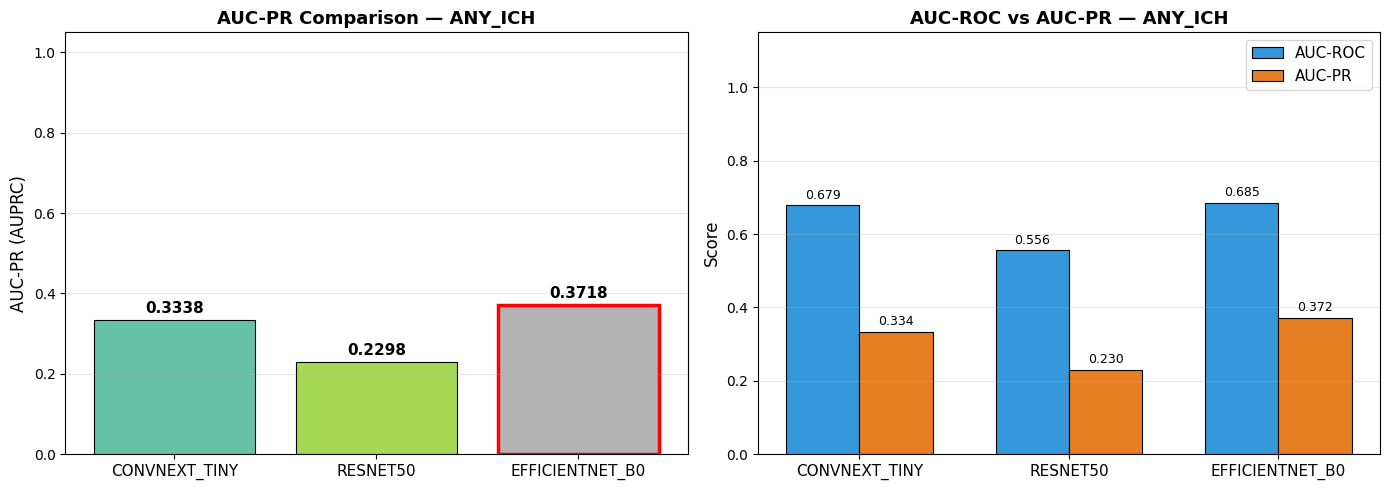


  AUC-PR (AUPRC) Results — ANY_ICH
  CONVNEXT_TINY         AUC-PR = 0.3338
  RESNET50              AUC-PR = 0.2298
  EFFICIENTNET_B0       AUC-PR = 0.3718


In [70]:
# ==============================================================
# Fig. 14 — AUC-PR (AUPRC) Comparison per Backbone
# ==============================================================
from sklearn.metrics import average_precision_score, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Bar chart of AUPRC ---
auprc_vals = {}
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    auprc_vals[bb_name] = average_precision_score(m["y_true"], m["y_pred"])

colors = plt.cm.Set2(np.linspace(0, 1, len(BACKBONE_NAMES)))
bars = axes[0].bar(range(len(BACKBONE_NAMES)),
                   [auprc_vals[b] for b in BACKBONE_NAMES],
                   color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_xticks(range(len(BACKBONE_NAMES)))
axes[0].set_xticklabels([b.upper() for b in BACKBONE_NAMES], fontsize=11)
axes[0].set_ylabel("AUC-PR (AUPRC)", fontsize=12)
axes[0].set_title(f"AUC-PR Comparison — {EXPERIMENT_NAME.upper()}", fontsize=13, fontweight="bold")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3, axis='y')

for bar, bb_name in zip(bars, BACKBONE_NAMES):
    val = auprc_vals[bb_name]
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

# Highlight the best
best_bb = max(auprc_vals, key=auprc_vals.get)
best_idx = BACKBONE_NAMES.index(best_bb)
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(2.5)

# --- Right: AUC-ROC vs AUC-PR side-by-side ---
x = np.arange(len(BACKBONE_NAMES))
width = 0.35

auc_roc_vals = [all_test_metrics[b]["auc"] if "auc" in all_test_metrics[b]
                else roc_auc_score(all_test_metrics[b]["y_true"], all_test_metrics[b]["y_pred"])
                for b in BACKBONE_NAMES]
auc_pr_vals = [auprc_vals[b] for b in BACKBONE_NAMES]

rects1 = axes[1].bar(x - width/2, auc_roc_vals, width, label='AUC-ROC', color='#3498db', edgecolor='black', linewidth=0.8)
rects2 = axes[1].bar(x + width/2, auc_pr_vals, width, label='AUC-PR', color='#e67e22', edgecolor='black', linewidth=0.8)

axes[1].set_xticks(x)
axes[1].set_xticklabels([b.upper() for b in BACKBONE_NAMES], fontsize=11)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_title(f"AUC-ROC vs AUC-PR — {EXPERIMENT_NAME.upper()}", fontsize=13, fontweight="bold")
axes[1].set_ylim(0, 1.15)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

for rect in rects1:
    axes[1].text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.01,
                 f"{rect.get_height():.3f}", ha='center', va='bottom', fontsize=9)
for rect in rects2:
    axes[1].text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.01,
                 f"{rect.get_height():.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"  AUC-PR (AUPRC) Results — {EXPERIMENT_NAME.upper()}")
print(f"{'='*60}")
for bb_name in BACKBONE_NAMES:
    print(f"  {bb_name.upper():20s}  AUC-PR = {auprc_vals[bb_name]:.4f}")
print(f"{'='*60}")

In [71]:
# ============================================================
# Table 3 — Pairwise McNemar's Test (Statistical Significance between Backbones)
# ============================================================
from itertools import combinations

# Build binary prediction arrays at optimal thresholds
binary_preds = {}
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    y_true = np.array(m["y_true"])
    y_prob = np.array(m["y_pred"])
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    opt_idx = np.argmax(j_scores)
    opt_thresh = thresholds[opt_idx]
    binary_preds[bb_name] = (y_prob >= opt_thresh).astype(int)

# Pairwise McNemar's
mcnemar_rows = []
for (a, b) in combinations(BACKBONE_NAMES, 2):
    y_true_a = np.array(all_test_metrics[a]["y_true"])
    pred_a = binary_preds[a]
    pred_b = binary_preds[b]
    
    n01 = np.sum((pred_a == y_true_a) & (pred_b != y_true_a))
    n10 = np.sum((pred_a != y_true_a) & (pred_b == y_true_a))
    
    if n01 + n10 > 0:
        chi2 = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
        from scipy.stats import chi2 as chi2_dist
        p_val = 1 - chi2_dist.cdf(chi2, df=1)
    else:
        chi2 = 0.0
        p_val = 1.0
    
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    mcnemar_rows.append({
        "Comparison": f"{a.upper()} vs {b.upper()}",
        "n_01 (A✓B✗)": int(n01),
        "n_10 (A✗B✓)": int(n10),
        "χ²": f"{chi2:.3f}",
        "p-value": f"{p_val:.4f}" if p_val >= 0.0001 else f"{p_val:.2e}",
        "Significance": sig
    })

df_mcnemar = pd.DataFrame(mcnemar_rows)
print("\n" + "=" * 100)
print(f"  TABLE 3: Pairwise McNemar's Test — Backbone Comparison ({EXPERIMENT_NAME.upper()})")
print("  (*** p<0.001, ** p<0.01, * p<0.05, ns = not significant)")
print("=" * 100)
display(df_mcnemar.style.set_properties(**{
    'text-align': 'center', 'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}
]))


  TABLE 3: Pairwise McNemar's Test — Backbone Comparison (ANY_ICH)
  (*** p<0.001, ** p<0.01, * p<0.05, ns = not significant)


,Comparison,n_01 (A✓B✗),n_10 (A✗B✓),χ²,p-value,Significance
0,CONVNEXT_TINY vs RESNET50,98,133,5.004,0.0253,*
1,CONVNEXT_TINY vs EFFICIENTNET_B0,236,97,57.189,3.96e-14,***
2,RESNET50 vs EFFICIENTNET_B0,277,103,78.761,0.00e+00,***
